In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


AssertionError: Did you change the path? It should be one of ['/home/export/soheuny/SRFinder/soheun/notebooks', '/home/soheuny/HH4bsim/soheun/notebooks']

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model
from dataset import MotherSamples
from events_data import events_from_scdinfo



features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3
plt.rcParams["legend.fontsize"] = 10

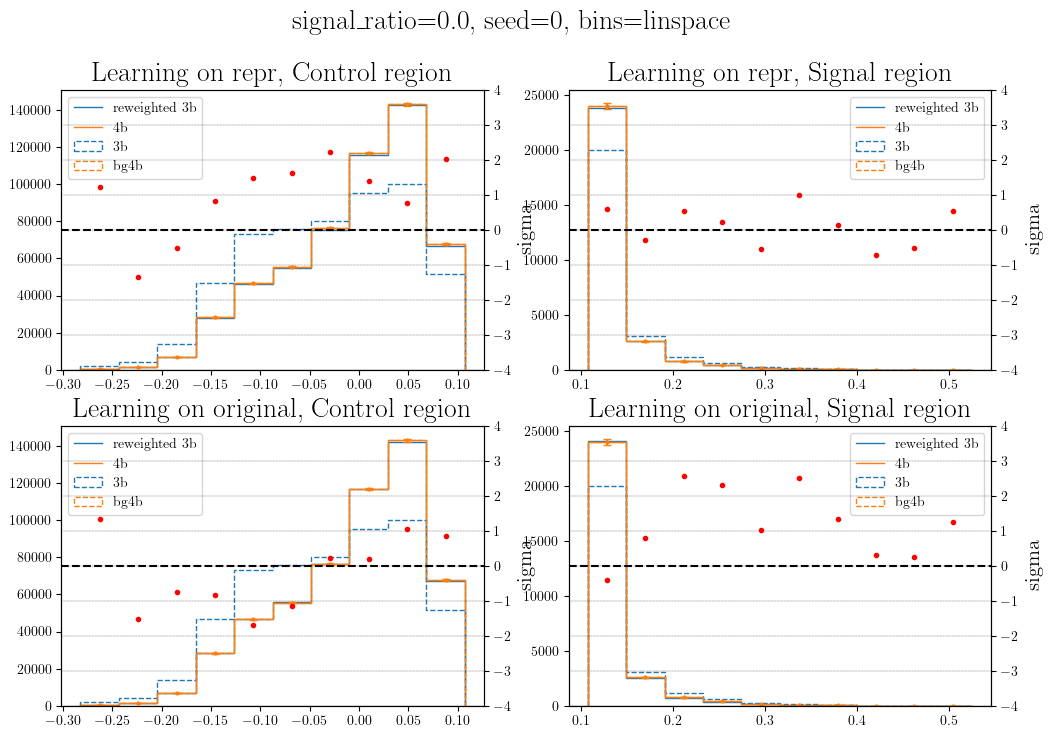

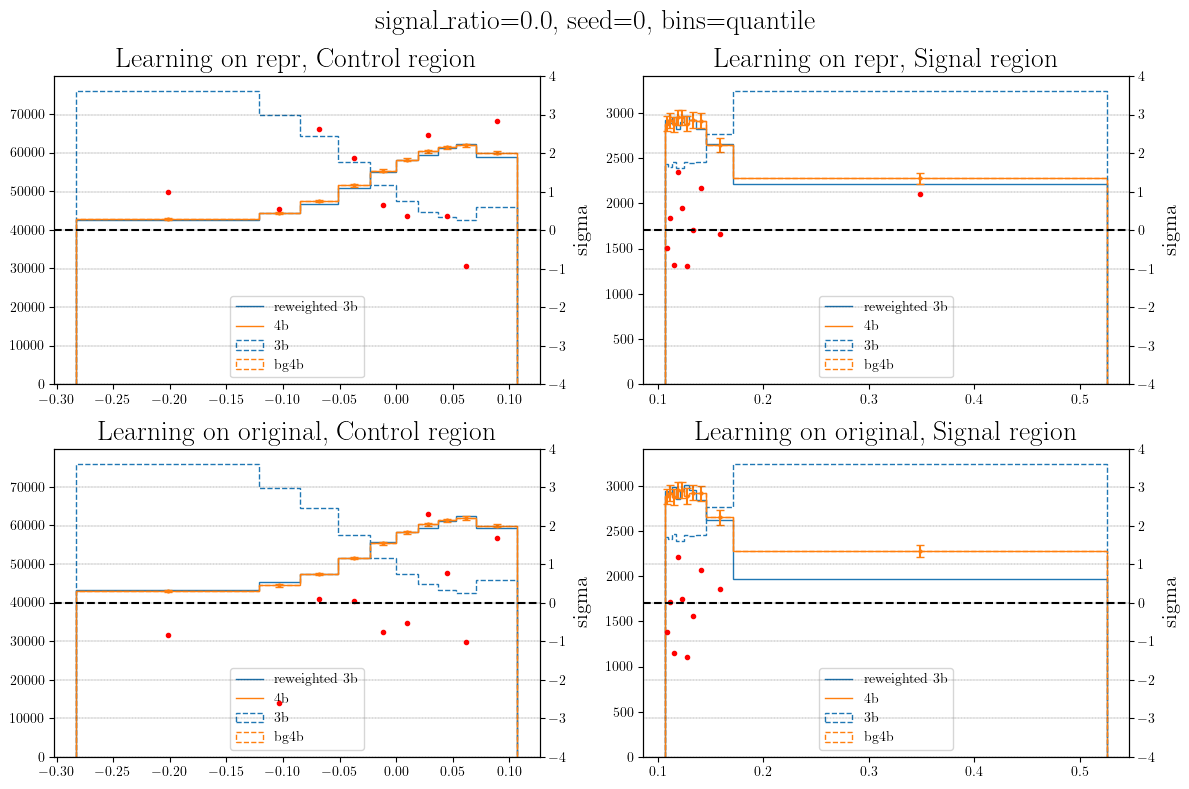

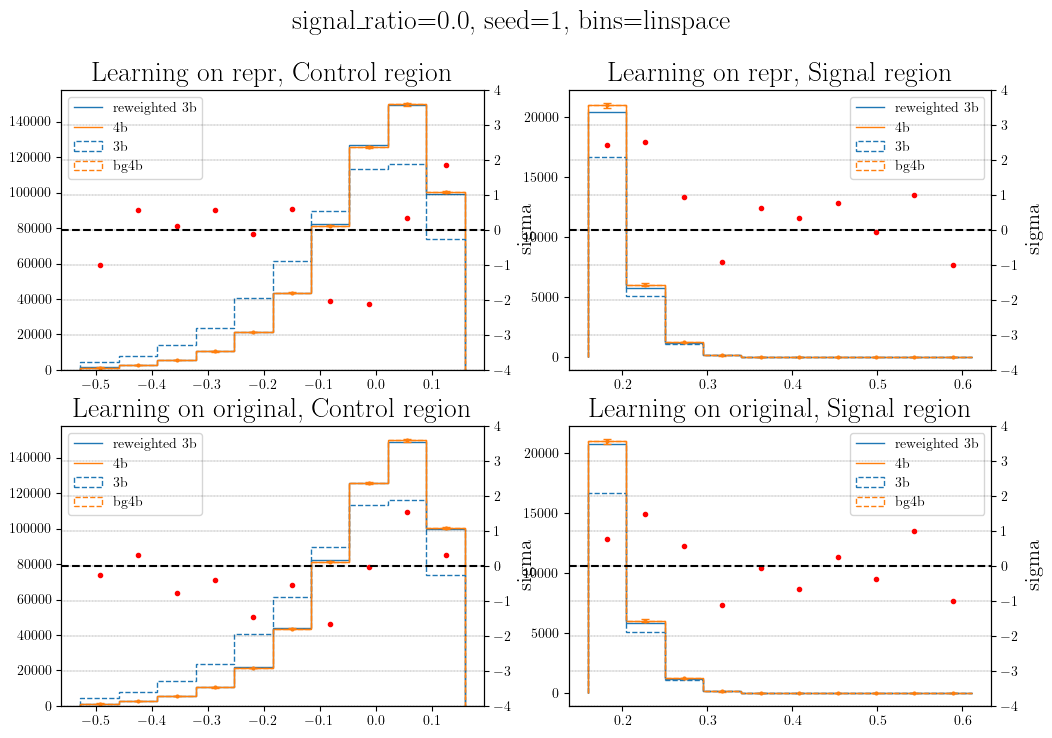

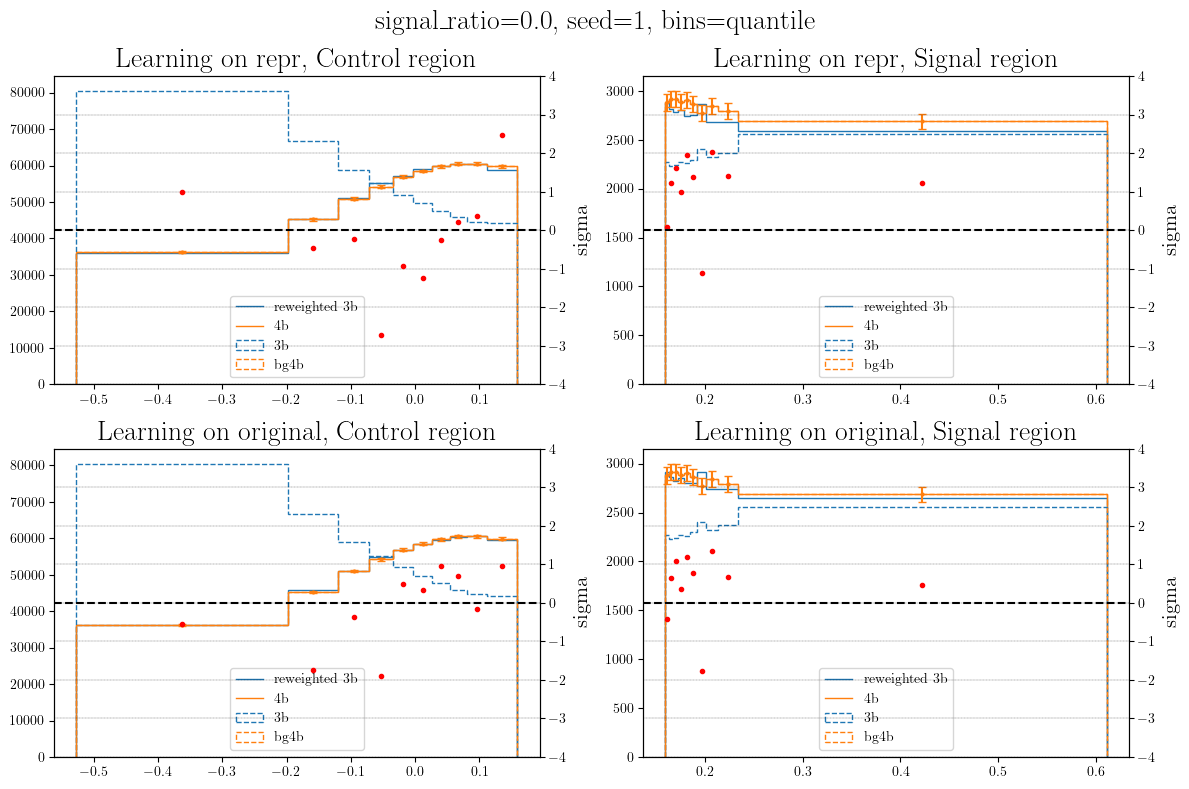

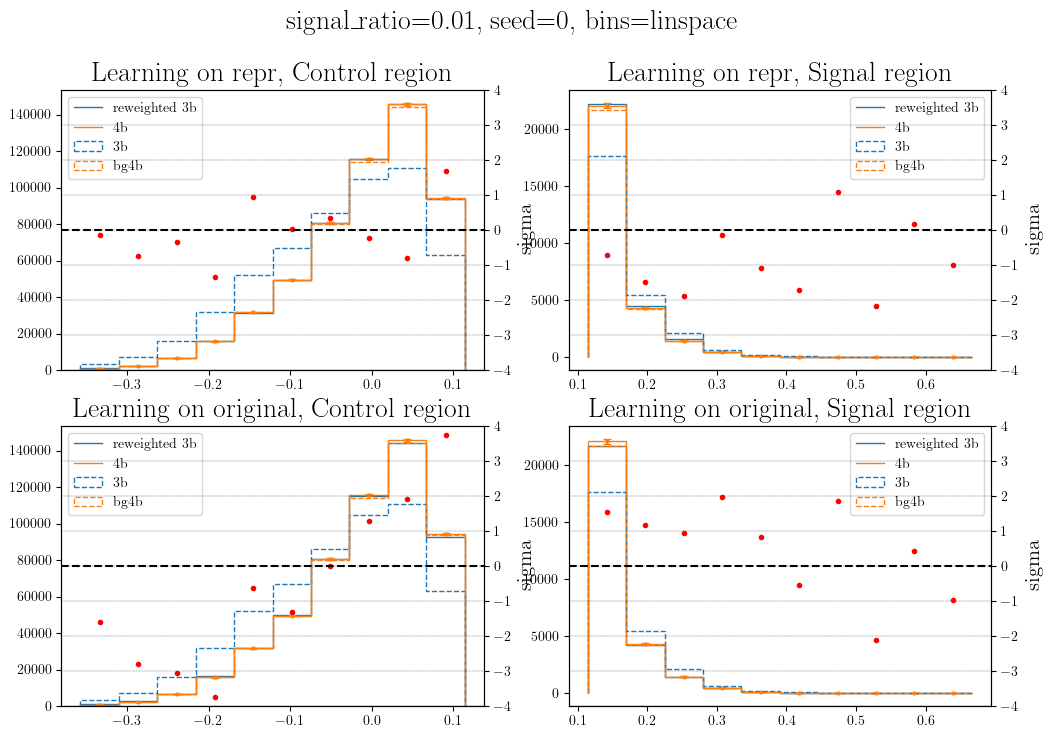

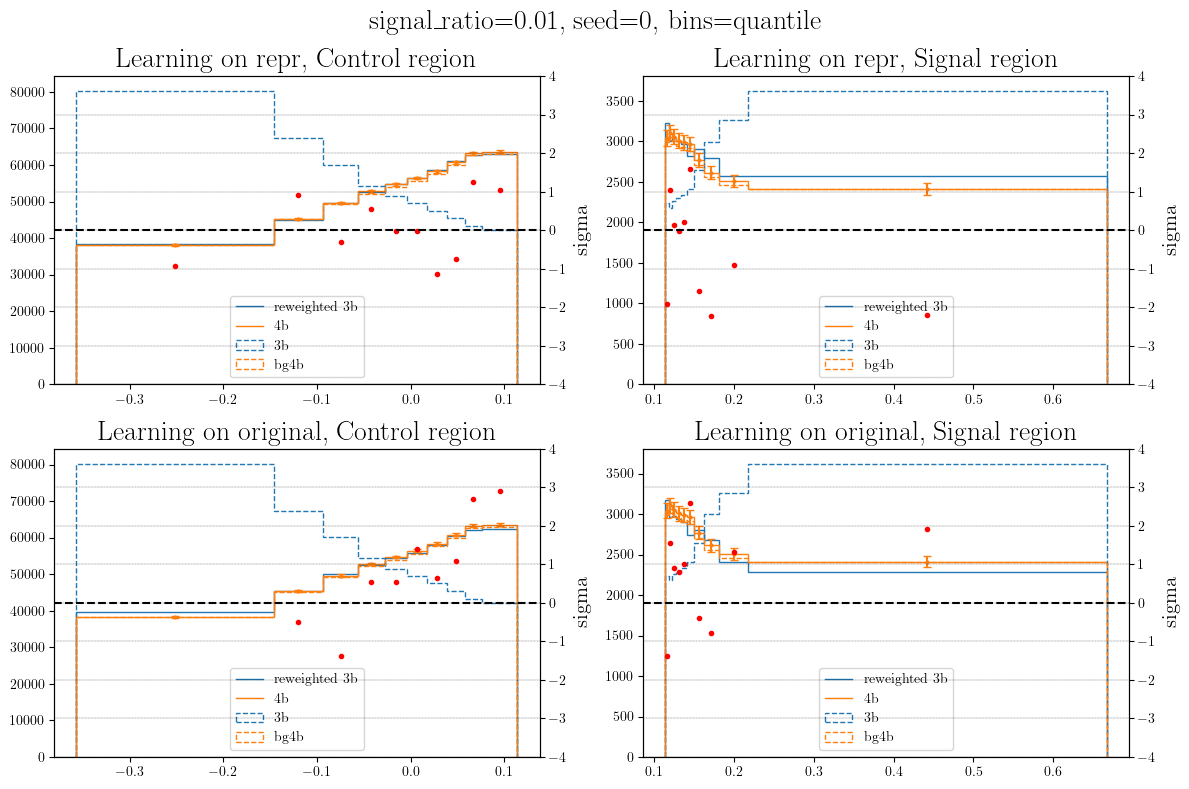

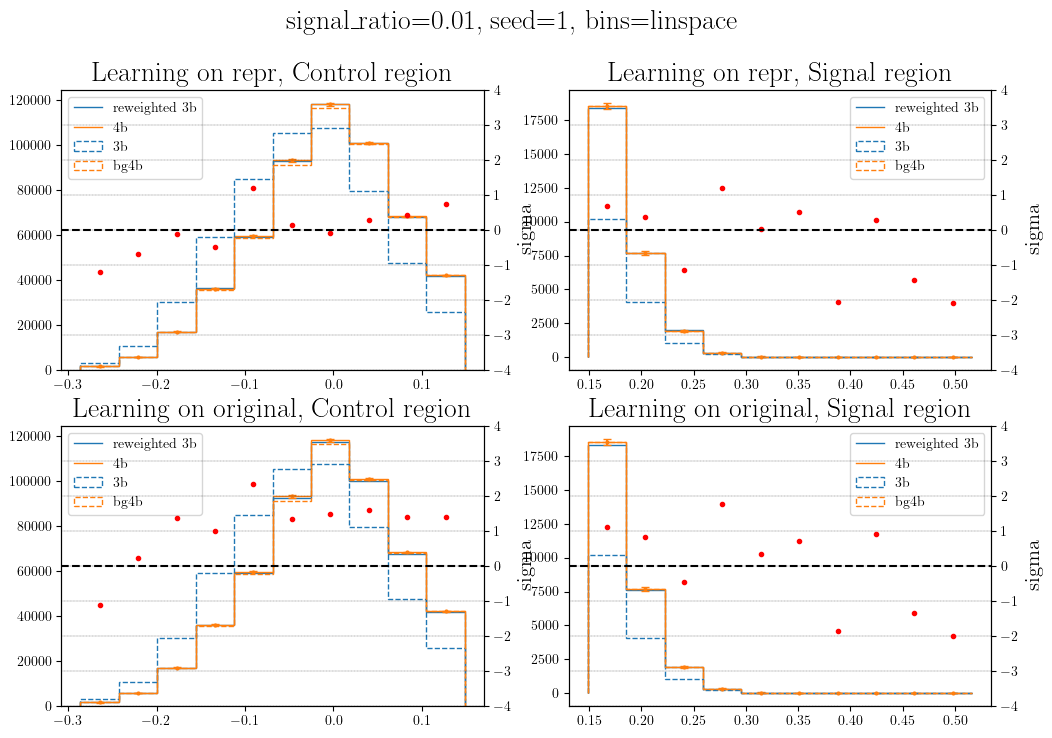

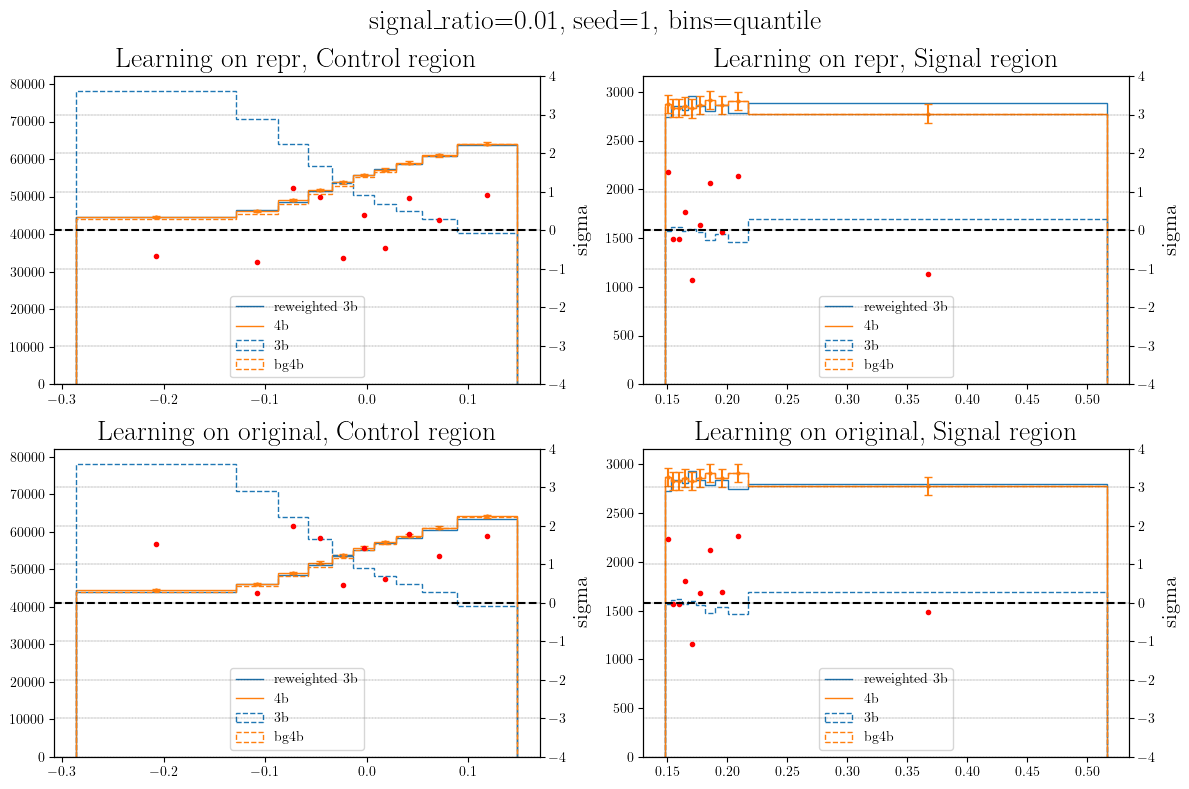

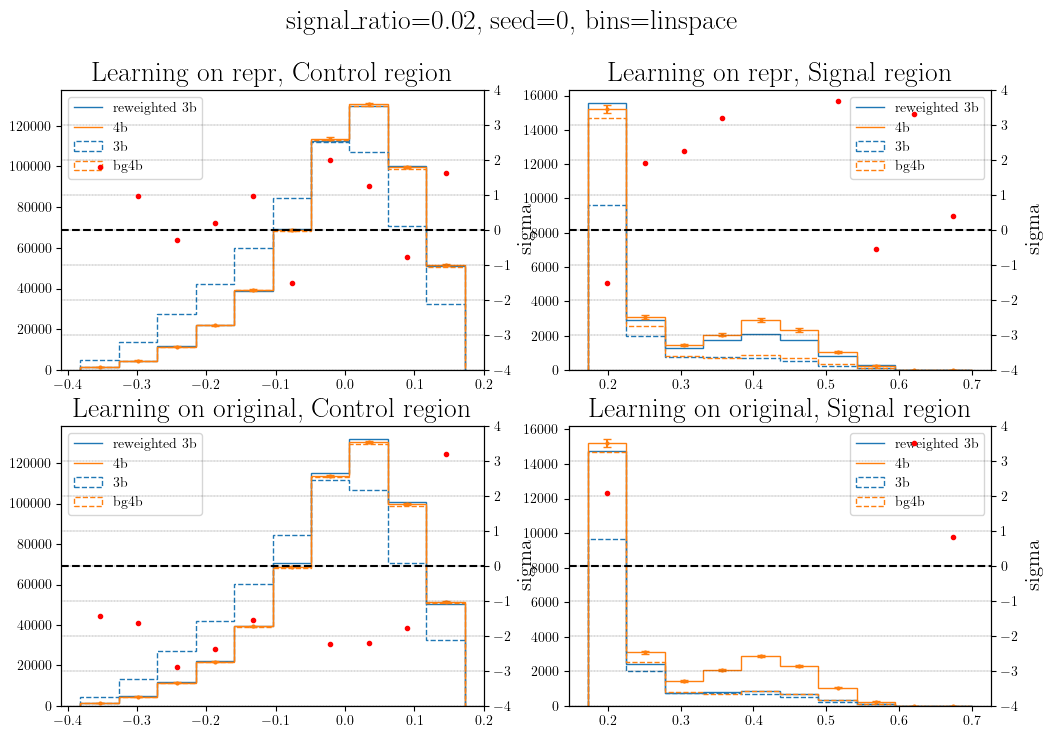

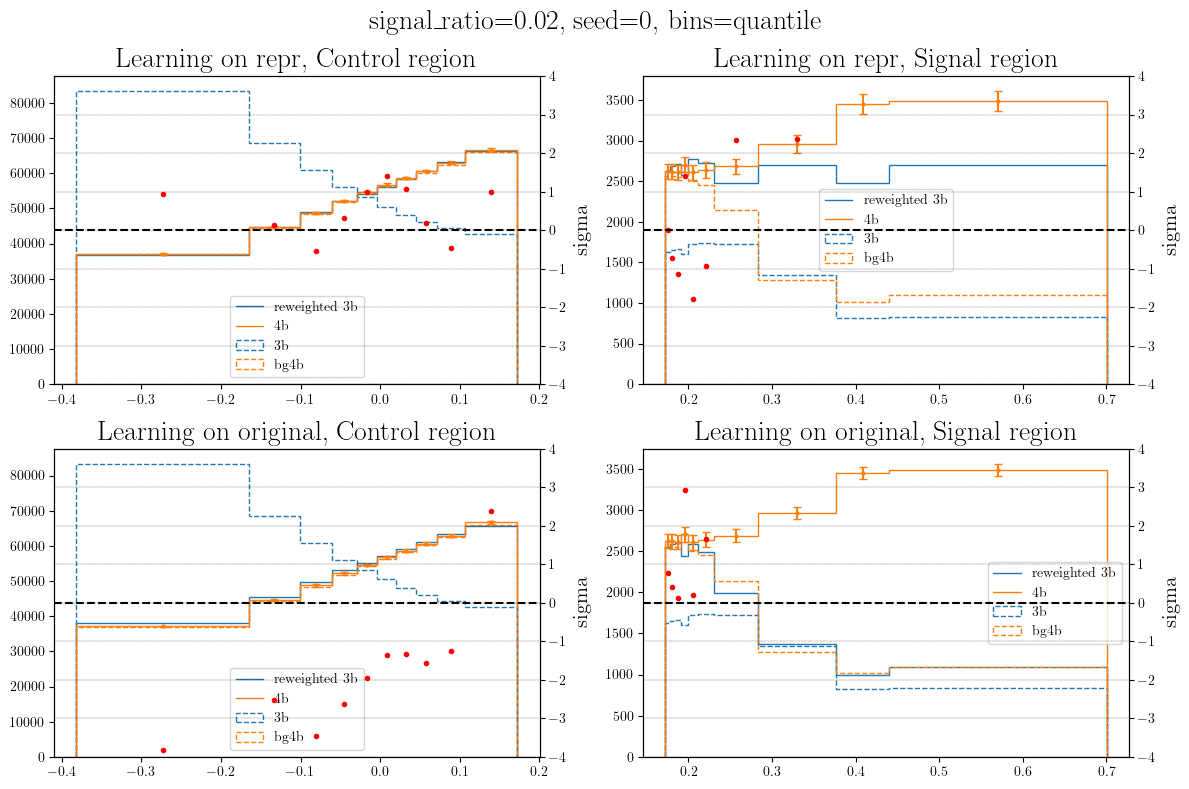

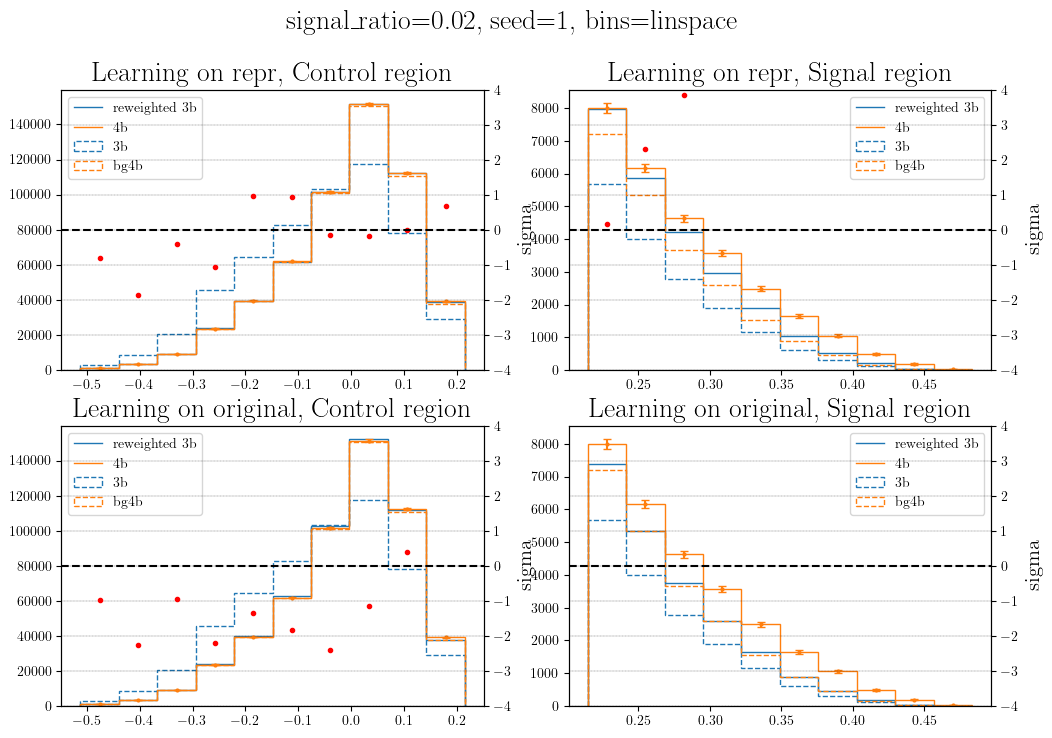

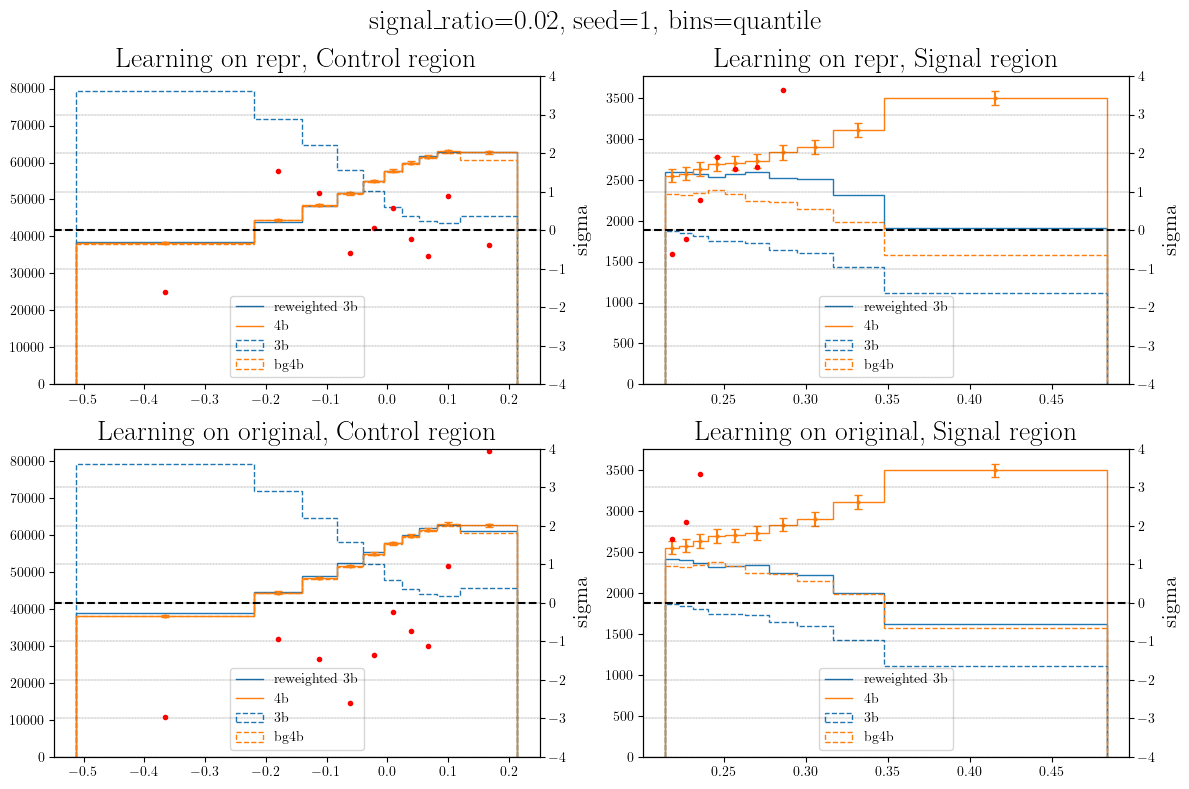

In [5]:
from signal_region import get_SR_CR_cut, get_DRs
import pandas as pd

n_3b = 100_0000
device = torch.device("cuda")
experiment_name = "CR_fvt_training_v2"
signal_filename = "HH4b_picoAOD.h5"
ratio_4b = 0.5
seeds = np.arange(2)
nbins = 10

CR_fvt_type = ["repr", "original"]

for signal_ratio in [0.0, 0.01, 0.02]:
    for seed in seeds:
        hparam_filter = {
            "experiment_name": experiment_name,
            "dataset": lambda x: all([x["seed"] == seed, 
                                x["n_3b"] == n_3b, 
                                x["signal_ratio"] == signal_ratio]),
            "aux_info_step": 3
        }
        hashes = TrainingInfo.find(hparam_filter)
        assert len(hashes) == 2
        
        CR_fvt_tinfos = [TrainingInfo.load(hash) for hash in hashes]
        for tinfo in CR_fvt_tinfos:
            if tinfo.hparams["model"] == "AttentionClassifier":
                CR_repr_fvt_tinfo = tinfo
            elif tinfo.hparams["model"] == "FvTClassifier":
                CR_orig_fvt_tinfo = tinfo

        assert CR_repr_fvt_tinfo.hparams["signal_region"] == CR_orig_fvt_tinfo.hparams["signal_region"]
            
        smeared_fvt_hash = CR_orig_fvt_tinfo.hparams["smeared_fvt_hash"]
        base_encoder_hash = CR_orig_fvt_tinfo.hparams["encoder_hash"]

        base_fvt_model = TrainingInfo.load(base_encoder_hash).load_trained_model(
            CR_orig_fvt_tinfo.hparams["encoder_mode"]
        )
        base_fvt_model.eval()
        base_fvt_model.to(torch.device("cuda"))
        base_fvt_model: FvTClassifier

        smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
        smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
            CR_orig_fvt_tinfo.hparams["encoder_mode"]
        )
        smeared_fvt_model.eval()
        smeared_fvt_model.to(torch.device("cuda"))

        # Use the same mother samples and exclude ones used for training base & smeared FvT model
        msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
        tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
        events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)
        # gamma_base, gamma_smeared, q_repr_tst = get_DRs(events_tst, base_fvt_model, smeared_fvt_model, return_repr=True)
        # SR_stats = np.log(gamma_base / gamma_smeared)
        q_repr_tst, _ = base_fvt_model.representations(events_tst.X_torch)
        
        events_train = events_from_scdinfo(msamples.scdinfo[smeared_fvt_tinfo.ms_idx], features, signal_filename)
        SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
        SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]

        SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_orig_fvt_tinfo.hparams["signal_region"])
        
        SR_idx = (SR_stats >= SR_cut)
        CR_idx = (SR_stats >= CR_cut) & (SR_stats < SR_cut)
        
        events_tst_SR = events_tst[SR_idx]
        events_tst_CR = events_tst[CR_idx]
        
        SR_stats_SR = SR_stats[SR_idx]
        SR_stats_CR = SR_stats[CR_idx]
        
        fig_linspace = plt.figure(figsize=(12, 8))
        fig_linspace.suptitle(f"signal_ratio={signal_ratio}, seed={seed}, bins=linspace")
        gs_linspace = GridSpec(2, 2, figure=fig_linspace)
        CR_bins_linspace = np.linspace(np.min(SR_stats_CR), np.max(SR_stats_CR), nbins + 1)
        SR_bins_linspace = np.linspace(np.min(SR_stats_SR), np.max(SR_stats_SR), nbins + 1)
        
        fig_quantile = plt.figure(figsize=(12, 8))
        fig_quantile.suptitle(f"signal_ratio={signal_ratio}, seed={seed}, bins=quantile")
        gs_quantile = GridSpec(2, 2, figure=fig_quantile)
        CR_bins_quantile = np.quantile(SR_stats_CR, np.linspace(0, 1, nbins + 1))
        SR_bins_quantile = np.quantile(SR_stats_SR, np.linspace(0, 1, nbins + 1))
        
        for ax_cnt, CR_fvt_type in enumerate(["repr", "original"]):
            CR_fvt_tinfo = CR_repr_fvt_tinfo if CR_fvt_type == "repr" else CR_orig_fvt_tinfo
            CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
            CR_fvt_model.eval()
            CR_fvt_model.to(torch.device("cuda"))
            
            if CR_fvt_type == "repr":
                CR_fvt_model: AttentionClassifier
                fvt_scores_CR_model = CR_fvt_model.predict(q_repr_tst)[:, 1].detach().cpu().numpy()
            else:
                CR_fvt_model: FvTClassifier
                fvt_scores_CR_model = CR_fvt_model.predict(events_tst.X_torch)[:, 1].detach().cpu().numpy()
                    
            fvt_scores_SR = fvt_scores_CR_model[SR_idx]
            reweights_SR = fvt_scores_SR / (1 - fvt_scores_SR)
            reweights_SR = np.where(events_tst_SR.is_4b, 1, -reweights_SR)
            
            fvt_scores_CR = fvt_scores_CR_model[CR_idx]
            reweights_CR = fvt_scores_CR / (1 - fvt_scores_CR)
            reweights_CR = np.where(events_tst_CR.is_4b, 1, -reweights_CR)
            
            
            for fig, gs, CR_bins, SR_bins in zip([fig_linspace, fig_quantile], [gs_linspace, gs_quantile], 
                                                 [CR_bins_linspace, CR_bins_quantile], [SR_bins_linspace, SR_bins_quantile]):
                ax = fig.add_subplot(gs[ax_cnt, 0])
                ax.set_title(f"Learning on {CR_fvt_type}, Control region")
                plot_rewighted_samples_by_model(events_tst_CR, SR_stats_CR, fvt_scores_CR, ax=ax, bins=CR_bins)
                ax.hist(SR_stats_CR[events_tst_CR.is_3b], bins=CR_bins, label="3b", histtype="step", linestyle="--", 
                        weights=events_tst_CR.weights[events_tst_CR.is_3b])
                ax.hist(SR_stats_CR[events_tst_CR.is_bg4b], bins=CR_bins, label="bg4b", histtype="step", linestyle="--", 
                        weights=events_tst_CR.weights[events_tst_CR.is_bg4b])
                ax.legend()
                ax = fig.add_subplot(gs[ax_cnt, 1])
                ax.set_title(f"Learning on {CR_fvt_type}, Signal region")
                plot_rewighted_samples_by_model(events_tst_SR, SR_stats_SR, fvt_scores_SR, ax=ax, bins=SR_bins)
                ax.hist(SR_stats_SR[events_tst_SR.is_3b], bins=SR_bins, label="3b", histtype="step", linestyle="--", 
                        weights=events_tst_SR.weights[events_tst_SR.is_3b])
                ax.hist(SR_stats_SR[events_tst_SR.is_bg4b], bins=SR_bins, label="bg4b", histtype="step", linestyle="--", 
                        weights=events_tst_SR.weights[events_tst_SR.is_bg4b])
                ax.legend()
            
                
        plt.tight_layout()
        plt.show()
        plt.close("all")

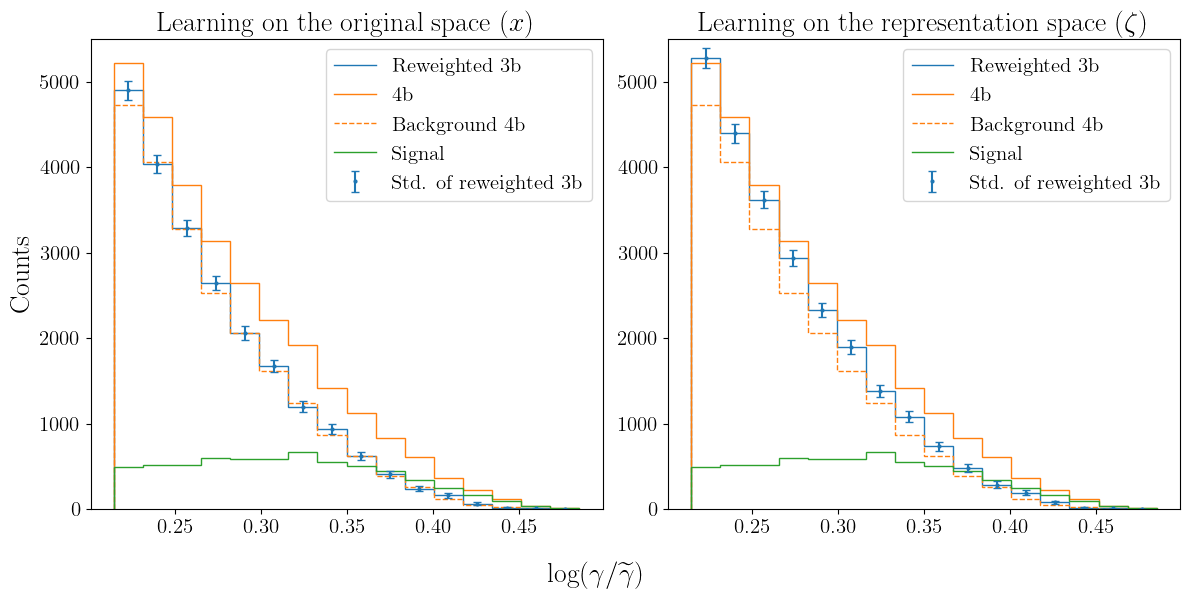

In [44]:
from signal_region import get_SR_CR_cut, get_DRs
import pandas as pd
from utils import get_quantiles_with_weights

plt.rcParams["legend.fontsize"] = 15
plt.rcParams["figure.titlesize"] = 25
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 20
# increase tick label size
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15

n_3b = 100_0000
device = torch.device("cuda")
experiment_name = "CR_fvt_training_v2"
signal_filename = "HH4b_picoAOD.h5"
ratio_4b = 0.5
nbins = 16
signal_ratio = 0.02
seed = 1
CR_fvt_type = ["repr", "original"]

hparam_filter = {
    "experiment_name": experiment_name,
    "dataset": lambda x: all([x["seed"] == seed, 
                        x["n_3b"] == n_3b, 
                        x["signal_ratio"] == signal_ratio]),
    "aux_info_step": 3
}
hashes = TrainingInfo.find(hparam_filter)
assert len(hashes) == 2

CR_fvt_tinfos = [TrainingInfo.load(hash) for hash in hashes]
for tinfo in CR_fvt_tinfos:
    if tinfo.hparams["model"] == "AttentionClassifier":
        CR_repr_fvt_tinfo = tinfo
    elif tinfo.hparams["model"] == "FvTClassifier":
        CR_orig_fvt_tinfo = tinfo

assert CR_repr_fvt_tinfo.hparams["signal_region"] == CR_orig_fvt_tinfo.hparams["signal_region"]
    
smeared_fvt_hash = CR_orig_fvt_tinfo.hparams["smeared_fvt_hash"]
base_encoder_hash = CR_orig_fvt_tinfo.hparams["encoder_hash"]

base_fvt_model = TrainingInfo.load(base_encoder_hash).load_trained_model(
    CR_orig_fvt_tinfo.hparams["encoder_mode"]
)
base_fvt_model.eval()
base_fvt_model.to(torch.device("cuda"))
base_fvt_model: FvTClassifier

smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
    CR_orig_fvt_tinfo.hparams["encoder_mode"]
)
smeared_fvt_model.eval()
smeared_fvt_model.to(torch.device("cuda"))

# Use the same mother samples and exclude ones used for training base & smeared FvT model
msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)
events_train = events_from_scdinfo(msamples.scdinfo[smeared_fvt_tinfo.ms_idx], features, signal_filename)
SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_orig_fvt_tinfo.hparams["signal_region"])

SR_idx = (SR_stats >= SR_cut)
CR_idx = (SR_stats >= CR_cut) & (SR_stats < SR_cut)

events_tst_SR = events_tst[SR_idx]
SR_stats_SR = SR_stats[SR_idx]

events_train_SR = events_train[SR_stats_train >= SR_cut]    
SR_stats_train_SR = SR_stats_train[SR_stats_train >= SR_cut]

q_repr_tst_SR, _ = base_fvt_model.representations(events_tst_SR.X_torch)
q_repr_train_SR, _ = base_fvt_model.representations(events_train_SR.X_torch)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
fig.supxlabel(r"$\log (\gamma / \widetilde{\gamma})$")

for ax_cnt, CR_fvt_type in enumerate(["original", "repr"]):
    if ax_cnt == 0:
        ax[ax_cnt].set_ylabel("Counts")
    CR_fvt_tinfo = CR_repr_fvt_tinfo if CR_fvt_type == "repr" else CR_orig_fvt_tinfo
    CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
    CR_fvt_model.eval()
    CR_fvt_model.to(torch.device("cuda"))
    
    if CR_fvt_type == "repr":
        CR_fvt_model: AttentionClassifier
        fvt_scores_SR = CR_fvt_model.predict(q_repr_tst_SR)[:, 1].detach().cpu().numpy()
        fvt_scores_SR_train = CR_fvt_model.predict(q_repr_train_SR)[:, 1].detach().cpu().numpy()
    else:
        CR_fvt_model: FvTClassifier
        fvt_scores_SR = CR_fvt_model.predict(events_tst_SR.X_torch)[:, 1].detach().cpu().numpy()
        fvt_scores_SR_train = CR_fvt_model.predict(events_train_SR.X_torch)[:, 1].detach().cpu().numpy()
        
    reweights_SR_train = fvt_scores_SR_train / (1 - fvt_scores_SR_train)
    reweights_SR_train = np.where(events_train_SR.is_4b, 1, reweights_SR_train)
    SR_bins = np.linspace(np.min(SR_stats_train_SR), np.max(SR_stats_train_SR), nbins + 1)
    # SR_bins = get_quantiles_with_weights(SR_stats_train_SR[events_train_SR.is_3b], 
    #                                     (reweights_SR_train * events_train_SR.weights)[events_train_SR.is_3b], 
    #                                     np.linspace(0, 1, nbins + 1))
        
    reweights_SR = fvt_scores_SR / (1 - fvt_scores_SR)
    reweights_SR = np.where(events_tst_SR.is_4b, 1, -reweights_SR)
    
    current_ax = ax[ax_cnt]
    CR_fvt_type_str = r"the representation space ($\zeta$)" if CR_fvt_type == "repr" else r"the original space ($x$)"
    current_ax.set_title(rf"Learning on {CR_fvt_type_str}")
    plot_rewighted_samples_by_model(events_tst_SR, SR_stats_SR, fvt_scores_SR, 
                                    ax=current_ax, bins=SR_bins, disable_twin_ax=True, errorbar="3b")
    hist_bg4b, _ = np.histogram(SR_stats_SR[events_tst_SR.is_bg4b], bins=SR_bins, 
                                weights=events_tst_SR.weights[events_tst_SR.is_bg4b])
    hist_signal, _ = np.histogram(SR_stats_SR[events_tst_SR.is_signal], bins=SR_bins, 
                                  weights=events_tst_SR.weights[events_tst_SR.is_signal])
    # current_ax.hist(SR_stats_SR[events_tst_SR.is_3b], bins=SR_bins, label="3b", histtype="step", linestyle="--", 
                    # weights=events_tst_SR.weights[events_tst_SR.is_3b])
    current_ax.stairs(hist_bg4b, SR_bins, label="Background 4b", color=plt.cm.tab10(1), linestyle="--")
    current_ax.stairs(hist_signal, SR_bins, label="Signal", color=plt.cm.tab10(2))
    current_ax.legend()
    current_ax.set_ylim(bottom=0, top=5500)
    
        
plt.tight_layout()
plt.savefig("./figures/on_which_to_learn.pdf", dpi=300)
plt.show()
plt.close("all")

# Calculate and save pulls

In [7]:
# import pickle
# from signal_region import get_SR_CR_cut, get_DRs
# import pandas as pd

# n_3b = 100_0000
# device = torch.device("cuda")
# experiment_name = "CR_fvt_training_v2"
# signal_filename = "HH4b_picoAOD.h5"
# ratio_4b = 0.5
# seeds = np.arange(50)
# nbins_range = [2**i for i in range(8)]


# for signal_ratio in [0.0, 0.01, 0.02]:
#     hparam_filter = {
#         "experiment_name": experiment_name,
#         "dataset": lambda x: all([x["seed"] in seeds, 
#                             x["n_3b"] == n_3b, 
#                             x["signal_ratio"] == signal_ratio]),
#         "aux_info_step": 3
#     }
#     hashes = TrainingInfo.find(hparam_filter)

#     for hash in tqdm.tqdm(hashes):
#         if os.path.exists("./data/tmp/hist_list_v2.pkl"):
#             hist_list = pickle.load(open("./data/tmp/hist_list_v2.pkl", "rb"))
#             if hash in [v["hash"] for v in hist_list]:
#                 continue
#         else:
#             hist_list = []
            
#         if os.path.exists("./data/tmp/pull_df_v2.tsv"):
#             pull_list = pd.read_csv("./data/tmp/pull_df_v2.tsv", sep="\t")
#             if hash in pull_list["hash"].values:
#                 continue
#         else:
#             pull_list = pd.DataFrame()
        
#         CR_fvt_tinfo = TrainingInfo.load(hash)
#         smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
#         base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]

#         base_fvt_model = TrainingInfo.load(base_encoder_hash).load_trained_model(
#             CR_fvt_tinfo.hparams["encoder_mode"]
#         )
#         base_fvt_model.eval()
#         base_fvt_model.to(torch.device("cuda"))

#         smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
#         smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
#             CR_fvt_tinfo.hparams["encoder_mode"]
#         )
#         smeared_fvt_model.eval()
#         smeared_fvt_model.to(torch.device("cuda"))

#         # Use the same mother samples and exclude ones used for training base & smeared FvT model
#         msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
#         events_base_train = events_from_scdinfo(msamples.scdinfo[smeared_fvt_tinfo.ms_idx], features, signal_filename)
#         tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
#         events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)
#         events_all = EventsData.merge([events_base_train, events_tst])
#         gamma_base_all, gamma_smeared_all, q_repr_base_all = get_DRs(events_all, base_fvt_model, smeared_fvt_model, return_repr=True)
#         gamma_base_train = gamma_base_all[: len(events_base_train)]
#         gamma_smeared_train = gamma_smeared_all[: len(events_base_train)]
#         gamma_base = gamma_base_all[len(events_base_train):]
#         gamma_smeared = gamma_smeared_all[len(events_base_train):]
#         q_repr_train = q_repr_base_all[: len(events_base_train)]
#         q_repr_tst = q_repr_base_all[len(events_base_train):]
#         SR_stats_train = np.log(gamma_base_train / gamma_smeared_train)
#         SR_stats = np.log(gamma_base / gamma_smeared)

#         SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_base_train, CR_fvt_tinfo.hparams["signal_region"])
        
#         SR_idx = (SR_stats >= SR_cut)
#         CR_idx = (SR_stats >= CR_cut) & (SR_stats < SR_cut)
        
#         events_tst_SR = events_tst[SR_idx]
#         events_tst_CR = events_tst[CR_idx]
        
#         model = CR_fvt_tinfo.hparams["model"]
        
#         CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
#         CR_fvt_model.eval()
#         CR_fvt_model.to(torch.device("cuda"))
        
#         if model == "AttentionClassifier":
#             CR_fvt_model: AttentionClassifier
#             fvt_scores_CR_model = CR_fvt_model.predict(q_repr_tst)[:, 1].detach().cpu().numpy()
#         else:
#             CR_fvt_model: FvTClassifier
#             fvt_scores_CR_model = CR_fvt_model.predict(events_tst.X_torch)[:, 1].detach().cpu().numpy()

#         fvt_scores_SR = fvt_scores_CR_model[SR_idx]
#         reweights_SR = fvt_scores_SR / (1 - fvt_scores_SR)
#         reweights_SR = np.where(events_tst_SR.is_4b, 1, -reweights_SR)
        
#         fvt_scores_CR = fvt_scores_CR_model[CR_idx]
#         reweights_CR = fvt_scores_CR / (1 - fvt_scores_CR)
#         reweights_CR = np.where(events_tst_CR.is_4b, 1, -reweights_CR)
        
#         SR_stats_SR = SR_stats[SR_idx]
#         SR_stats_CR = SR_stats[CR_idx]
        
#         for mode in ["linspace", "quantile"]:
#             for nbins in nbins_range:
#                 if mode == "linspace":
#                     bins_SR = np.linspace(SR_cut, np.max(SR_stats_train), nbins + 1)
#                     bins_CR = np.linspace(CR_cut, SR_cut, nbins + 1)
#                 elif mode == "quantile":
#                     bins_SR = np.quantile(SR_stats_train[SR_stats_train >= SR_cut], np.linspace(0, 1, nbins + 1))
#                     bins_CR = np.quantile(SR_stats_train[(SR_stats_train < SR_cut) & (SR_stats_train >= CR_cut)], np.linspace(0, 1, nbins + 1))
                
#                 diff_SR_hist = np.histogram(SR_stats_SR, bins=bins_SR, weights=reweights_SR * events_tst_SR.weights)[0]
#                 sq_SR_hist = np.histogram(SR_stats_SR, bins=bins_SR, weights=reweights_SR**2 * events_tst_SR.weights**2)[0]
#                 diff_CR_hist = np.histogram(SR_stats_CR, bins=bins_CR, weights=reweights_CR * events_tst_CR.weights)[0]
#                 sq_CR_hist = np.histogram(SR_stats_CR, bins=bins_CR, weights=reweights_CR**2 * events_tst_CR.weights**2)[0]
                
#                 # Normalize
                
#                 samples_exist_SR = sq_SR_hist > 0
#                 df_SR = np.sum(samples_exist_SR)
#                 pull_SR = diff_SR_hist[samples_exist_SR] / np.sqrt(sq_SR_hist[samples_exist_SR])
#                 pull_SR = np.sqrt(np.mean(pull_SR ** 2))
                
#                 samples_exist_CR = sq_CR_hist > 0
#                 df_CR = np.sum(samples_exist_CR)
#                 pull_CR = diff_CR_hist[samples_exist_CR] / np.sqrt(sq_CR_hist[samples_exist_CR])
#                 pull_CR = np.sqrt(np.mean(pull_CR ** 2))
                
#                 pull_list = pd.concat([pull_list, pd.DataFrame(
#                     [
#                         {
#                             "hash": hash, "model": model, "signal_ratio": signal_ratio, 
#                             "mode": mode, "nbins": nbins, "pull": pull_SR, "df": df_SR, "region": "SR"
#                         },
#                         {
#                             "hash": hash, "model": model, "signal_ratio": signal_ratio, 
#                             "mode": mode, "nbins": nbins, "pull": pull_CR, "df": df_CR, "region": "CR"
#                         }
#                     ]
#                 )])
                
#                 hist_list.extend([
#                     {"hash": hash, "model": model, "signal_ratio": signal_ratio, 
#                         "mode": mode, "nbins": nbins, "diff_SR": diff_SR_hist, "sq_SR": sq_SR_hist, 
#                         "diff_CR": diff_CR_hist, "sq_CR": sq_CR_hist}
#                 ])
#                 # check if any of pull_SR or pull_CR is nan or inf
#                 assert not np.any(np.isnan(pull_SR))
#                 assert not np.any(np.isnan(pull_CR))
#                 assert not np.any(np.isinf(pull_SR))
#                 assert not np.any(np.isinf(pull_CR))

#         pull_list.to_csv("./data/tsv/pull_df_v2.tsv", sep="\t", index=False)
#         with open("./data/tmp/hist_list_v2.pkl", "wb") as f:
#             pickle.dump(hist_list, f)

100%|██████████| 100/100 [00:02<00:00, 34.19it/s]


In [23]:
# from itertools import product
# import pickle
# import tqdm
# from scipy import stats
# import pandas as pd

# hist_list = pickle.load(open("./data/tmp/hist_list.pkl", "rb"))

# CR_fvt_mode = "best"
# mode = "quantile"
# learning_mode = "orig"
# model = "AttentionClassifier" if learning_mode == "repr" else "FvTClassifier"
# nbins = 2**4
# unit_bins = nbins // 4
# starts = np.arange(0, nbins, unit_bins)
# ends = np.arange(unit_bins, nbins + 1, unit_bins)
# min_n_weights = 0

# # pull_by_bins = {signal_ratio: [] for signal_ratio in [0.0, 0.01, 0.02]}

# rej_list = []

# for start, end in tqdm.tqdm(product(starts, ends)):
#     tmp_list = []
#     if start >= end:
#         continue
#     start_idx = int(start)
#     end_idx = int(end)
#     for v in hist_list:
#         if v["CR_fvt_mode"] == CR_fvt_mode and v["mode"] == mode and v["nbins"] == nbins and model == v["model"]:
#             diff_SR = v["diff_SR"]
#             diff_CR = v["diff_CR"]
#             sq_SR = v["sq_SR"]
#             sq_CR = v["sq_CR"]
            
#             diff = diff_SR[start_idx:end_idx]
#             sq = sq_SR[start_idx:end_idx]
            
#             samples_enough = np.sqrt(sq) > min_n_weights
#             df = np.sum(samples_enough)
            
#             if df == 0:
#                 continue
            
#             pull = diff[samples_enough] / np.sqrt(sq[samples_enough])
#             pull = np.sqrt(np.mean(pull ** 2))
            
#             tmp_list.append({
#                 "signal_ratio": v["signal_ratio"],
#                 "pull": pull,
#                 "df": df
#             })
            
#             rej_list.append({
#                 "start": start, "end": end, "signal_ratio": v["signal_ratio"], 
#                 "pull": pull, "df": df
#             })
            
#     if len(tmp_list) == 0:
#         continue
    
#     df_array = np.array([v["df"] for v in tmp_list])
#     z = stats.chi2.ppf(0.95, df=df_array)
#     z = np.sqrt(z / df_array)
#     tmp_df = pd.DataFrame(tmp_list)
#     tmp_df["rejected"] = tmp_df["pull"] > z
#     rej = tmp_df.groupby(["signal_ratio"])["rejected"].mean()
#     # if (rej.loc[0.0] <= 0.1) & (rej.loc[0.02] - rej.loc[0.01] > 0.1):
#     # if (rej.loc[0.0] <= 0.1) & (rej.loc[0.02] >= 0.5):
#     if rej.loc[0.0] <= 0.1:
#     # if rej.loc[0.02] >= 0.66:
#         print(f"start={start}, end={end}")
#         print(rej)
        
    
# rej_df = pd.DataFrame(rej_list)
# z = stats.chi2.ppf(0.95, df=rej_df["df"])
# z = np.sqrt(z / rej_df["df"])
# rej_df["z"] = z
# rej_df["rejected"] = rej_df["pull"] > rej_df["z"]

16it [00:00, 282.45it/s]

start=0, end=4
signal_ratio
0.00    0.08
0.01    0.16
0.02    0.16
Name: rejected, dtype: float64
start=0, end=8
signal_ratio
0.00    0.10
0.01    0.26
0.02    0.24
Name: rejected, dtype: float64
start=0, end=12
signal_ratio
0.00    0.06
0.01    0.38
0.02    0.40
Name: rejected, dtype: float64
start=4, end=8
signal_ratio
0.00    0.06
0.01    0.24
0.02    0.18
Name: rejected, dtype: float64
start=4, end=12
signal_ratio
0.00    0.08
0.01    0.34
0.02    0.40
Name: rejected, dtype: float64
start=8, end=12
signal_ratio
0.00    0.06
0.01    0.36
0.02    0.42
Name: rejected, dtype: float64


In [30]:
from signal_region import get_SR_CR_cut
import pandas as pd

n_3b = 100_0000
device = torch.device("cuda")
experiment_name = "CR_fvt_training"
signal_filename = "HH4b_picoAOD.h5"
ratio_4b = 0.5
seeds = np.arange(50)

SR_info_dict = []
hparam_filter = {
    "experiment_name": experiment_name,
    "dataset": lambda x: all([x["seed"] in seeds, 
                        x["n_3b"] == n_3b, 
                        x["signal_ratio"] in [0.0, 0.01, 0.02]]),
    "aux_info_step": 3
}
hashes = TrainingInfo.find(hparam_filter)

for hash in tqdm.tqdm(hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash)
    smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
    base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]

    base_fvt_model = TrainingInfo.load(base_encoder_hash).load_trained_model("best")
    smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
    
    # Use the same mother samples and exclude ones used for training base & smeared FvT model
    msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
    tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
    events_train = events_from_scdinfo(msamples.scdinfo[smeared_fvt_tinfo.ms_idx], features, signal_filename)
    events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)
    SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
    SR_stats_tst = smeared_fvt_tinfo.aux_info["SR_stats_tst"]

    SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"])
            
    SR_idx = (SR_stats_tst >= SR_cut)
    CR_idx = (SR_stats_tst >= CR_cut) & (SR_stats_tst < SR_cut)
    
    events_tst_SR = events_tst[SR_idx]
    events_tst_CR = events_tst[CR_idx]
    
    if CR_fvt_tinfo.hparams["dataset"]["signal_ratio"] > 0:
        concentration_SR = events_tst_SR.total_weight_signal / (events_tst_CR.total_weight_signal + events_tst_SR.total_weight_signal)
    else:
        concentration_SR = 0
    size_SR = events_tst_SR.total_weight_4b / (events_tst_CR.total_weight_4b + events_tst_SR.total_weight_4b)
    SR_info_dict.append(
        {
            "hash": hash, 
            "concentration_SR": concentration_SR, "size_SR": size_SR
        }
    )

100%|██████████| 300/300 [22:04<00:00,  4.42s/it]


In [31]:
SR_info_df = pd.DataFrame(SR_info_dict)
SR_info_df.to_csv("./data/tsv/SR_info_df.tsv", sep="\t", index=False)

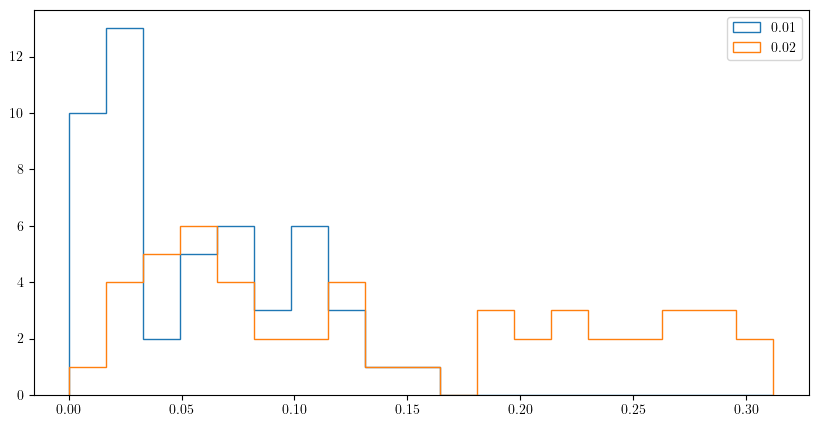

In [22]:
SR_info_dict[0.01] = np.array(SR_info_dict[0.01])
SR_info_dict[0.02] = np.array(SR_info_dict[0.02])

min_ratio = 0.0
max_ratio = np.max([np.max(0.01 * SR_info_dict[0.01][:, 0] / SR_info_dict[0.01][:, 1]), 
                    np.max(0.02 * SR_info_dict[0.02][:, 0] / SR_info_dict[0.02][:, 1])])
bins = np.linspace(min_ratio, max_ratio, 20)
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
axs.hist(0.01 * SR_info_dict[0.01][:, 0] / SR_info_dict[0.01][:, 1], bins=bins, label="0.01", histtype="step")
axs.hist(0.02 * SR_info_dict[0.02][:, 0] / SR_info_dict[0.02][:, 1], bins=bins, label="0.02", histtype="step")
plt.legend()
plt.show()

plt.close("all")

In [19]:
np.mean(SR_info_dict[0.01][:, 0] / SR_info_dict[0.01][:, 1]), np.std(SR_info_dict[0.01][:, 0] / SR_info_dict[0.01][:, 1])

(5.536457, 4.212568)

In [20]:
np.mean(SR_info_dict[0.02][:, 0] / SR_info_dict[0.02][:, 1]), np.std(SR_info_dict[0.02][:, 0] / SR_info_dict[0.02][:, 1])

(7.093787, 4.6884465)

In [72]:
from itertools import product
import pickle
import tqdm
from scipy import stats
import pandas as pd

hist_list = pickle.load(open("./data/tmp/hist_list.pkl", "rb"))

CR_fvt_mode = "best"
mode = "quantile"
learning_mode = "repr"
model = "AttentionClassifier" if learning_mode == "repr" else "FvTClassifier"
nbins = 2**4
# unit_bins = nbins // 4
unit_bins = 1
starts = np.arange(0, nbins, unit_bins)
ends = np.arange(unit_bins, nbins + 1, unit_bins)
min_n_weights = 0

# pull_by_bins = {signal_ratio: [] for signal_ratio in [0.0, 0.01, 0.02]}

rej_list = []

for start, end in tqdm.tqdm(product(starts, ends)):
    tmp_list = []
    if start >= end:
        continue
    start_idx = int(start)
    end_idx = int(end)
    for v in hist_list:
        if v["CR_fvt_mode"] == CR_fvt_mode and v["mode"] == mode and v["nbins"] == nbins and model == v["model"]:
            diff_SR = v["diff_SR"]
            diff_CR = v["diff_CR"]
            sq_SR = v["sq_SR"]
            sq_CR = v["sq_CR"]
            
            diff_SR = diff_SR[start_idx:end_idx]
            sq_SR = sq_SR[start_idx:end_idx]
            
            diff_CR = diff_CR[start_idx:end_idx]
            sq_CR = sq_CR[start_idx:end_idx]
            
            samples_enough_SR = np.sqrt(sq_SR) > min_n_weights
            samples_enough_CR = np.sqrt(sq_CR) > min_n_weights
            df_SR = np.sum(samples_enough_SR)
            df_CR = np.sum(samples_enough_CR)
            
            if df_SR == 0:
                continue
            
            pull_SR = diff_SR[samples_enough_SR] / np.sqrt(sq_SR[samples_enough_SR])
            pull_SR = np.sqrt(np.mean(pull_SR ** 2))
            
            pull_CR = diff_CR[samples_enough_CR] / np.sqrt(sq_CR[samples_enough_CR])
            pull_CR = np.sqrt(np.mean(pull_CR ** 2))
            
            tmp_list.append({
                "signal_ratio": v["signal_ratio"],
                "pull_SR": pull_SR, "pull_CR": pull_CR,
                "df_SR": df_SR, "df_CR": df_CR, 
                "hash": v["hash"]
            })
            
            rej_list.append({
                "start": start, "end": end, "signal_ratio": v["signal_ratio"], 
                "pull_SR": pull_SR, "pull_CR": pull_CR,
                "df_SR": df_SR, "df_CR": df_CR, 
                "hash": v["hash"]
            })
            
    if len(tmp_list) == 0:
        continue
    
    df_array = np.array([v["df_SR"] for v in tmp_list])
    z = stats.chi2.ppf(0.95, df=df_array)
    z = np.sqrt(z / df_array)
    tmp_df = pd.DataFrame(tmp_list)
    tmp_df["rejected_SR"] = tmp_df["pull_SR"] > z
    
    df_array = np.array([v["df_CR"] for v in tmp_list])
    z = stats.chi2.ppf(0.95, df=df_array)
    z = np.sqrt(z / df_array)
    tmp_df["rejected_CR"] = tmp_df["pull_CR"] > z

256it [00:00, 260.45it/s]


In [73]:
pull_SR_merged = pd.merge(tmp_df, SR_info_df, on="hash")

thrs = np.linspace(np.min(pull_SR_merged["pull_SR"]), np.max(pull_SR_merged["pull_SR"]), 1000)

for signal_ratio in [0.0, 0.01, 0.02]:
    selected = pull_SR_merged["signal_ratio"] == signal_ratio
    rej_SR = np.mean((pull_SR_merged["pull_SR"][selected].values.reshape(-1, 1) - thrs) > 0, axis=0)
    rej_CR = np.mean((pull_SR_merged["pull_CR"][selected].values.reshape(-1, 1) - thrs) > 0, axis=0)
    plt.plot(thrs, rej_SR, label=f"{signal_ratio}")
plt.legend()
plt.show()

NameError: name 'SR_info_df' is not defined

/home/export/soheuny/.conda/envs/coffea_torch/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/export/soheuny/.conda/envs/coffea_torch/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


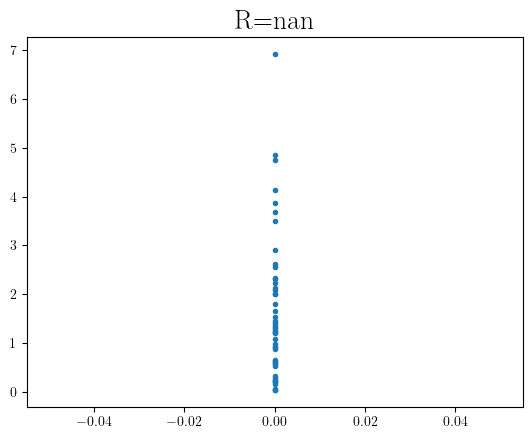

In [46]:
selected = pull_SR_merged["signal_ratio"] == 0.0
sr = pull_SR_merged["concentration_SR"] / pull_SR_merged["size_SR"] * pull_SR_merged["signal_ratio"]
pull = pull_SR_merged["pull_SR"]
plt.plot(sr[selected], pull[selected], "o")
plt.title(f"R={np.corrcoef(sr[selected], pull[selected])[0, 1]:.3f}")
plt.show()

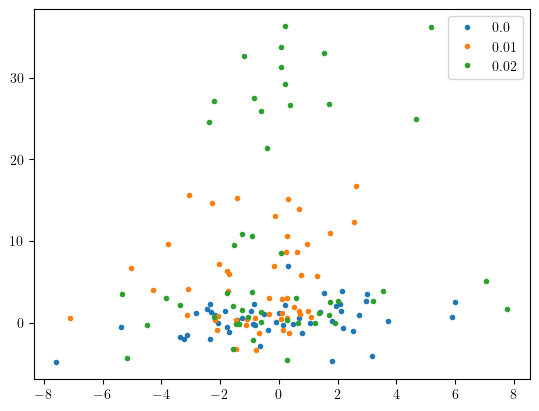

In [61]:
for signal_ratio in [0.0, 0.01, 0.02]:
    plt.plot(pull_SR_merged["pull_CR"][pull_SR_merged["signal_ratio"] == signal_ratio], 
             pull_SR_merged["pull_SR"][pull_SR_merged["signal_ratio"] == signal_ratio], "o", label=f"{signal_ratio}")
plt.legend()
plt.show()

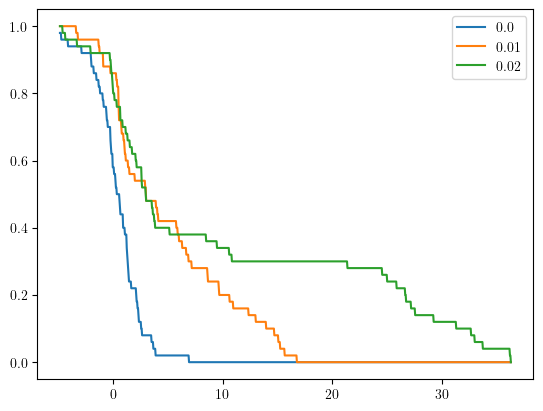

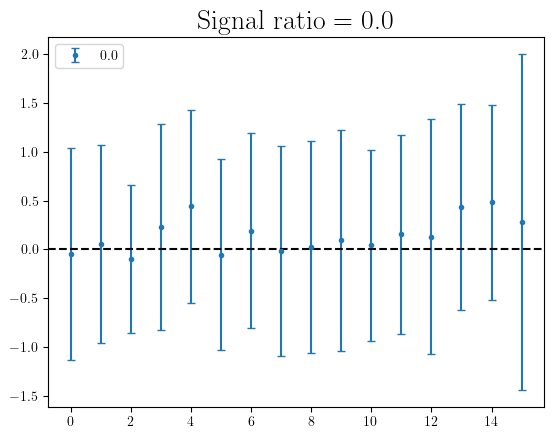

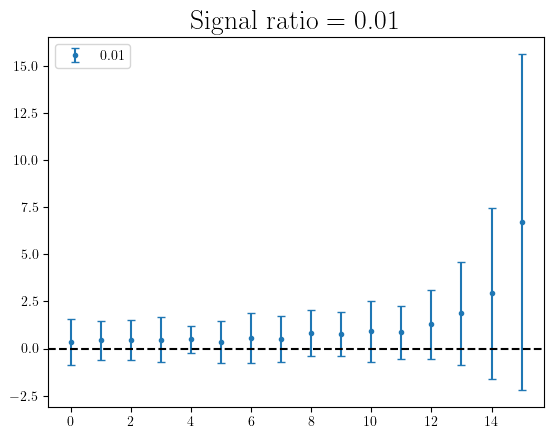

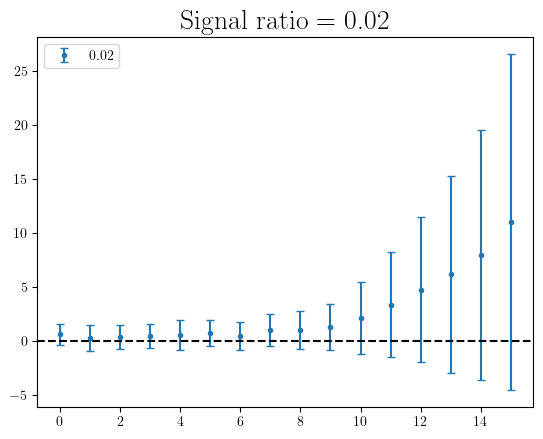

In [12]:
from itertools import product
import pickle
import tqdm
from scipy import stats
import pandas as pd

hist_list = pickle.load(open("./data/tmp/hist_list_v2.pkl", "rb"))

CR_fvt_mode = "best"
mode = "quantile"
learning_mode = "orig"
model = "AttentionClassifier" if learning_mode == "repr" else "FvTClassifier"
nbins = 2**4

pull_df = []
pull_SR_list = []
pull_CR_list = []
for v in hist_list:
    if v["mode"] == mode and v["nbins"] == nbins and model == v["model"]:
        diff_SR = v["diff_SR"]
        diff_CR = v["diff_CR"]
        sq_SR = v["sq_SR"]
        sq_CR = v["sq_CR"]
        pull_SR = diff_SR / np.sqrt(sq_SR)
        pull_CR = diff_CR / np.sqrt(sq_CR)
        pull_SR_list.append(pull_SR)
        pull_CR_list.append(pull_CR)
        pull_df.append({
            "signal_ratio": v["signal_ratio"],
            "hash": v["hash"]
        })
        
pull_df = pd.DataFrame(pull_df)
pull_SR_array = np.stack(pull_SR_list, axis=0)
pull_CR_array = np.stack(pull_CR_list, axis=0)
pull_SR_df = pd.DataFrame(pull_SR_array, columns=[f"pull_SR_{i}" for i in range(nbins)])
pull_CR_df = pd.DataFrame(pull_CR_array, columns=[f"pull_CR_{i}" for i in range(nbins)])
pull_df = pd.concat([pull_df, pull_SR_df, pull_CR_df], axis=1)

for signal_ratio in [0.0, 0.01, 0.02]:
    pull_SRs = pull_df.loc[pull_df["signal_ratio"] == signal_ratio, [f"pull_SR_{i}" for i in range(nbins)]].values
    pull_CRs = pull_df.loc[pull_df["signal_ratio"] == signal_ratio, [f"pull_CR_{i}" for i in range(nbins)]].values

    plt.title(f"Signal ratio = {signal_ratio}")
    # plt.boxplot(pull_SRs, positions=np.arange(nbins), widths=0.5, labels=np.arange(nbins))
    plt.errorbar(np.arange(nbins), pull_SRs.mean(axis=0), yerr=pull_SRs.std(axis=0), fmt="o", capsize=3, label=signal_ratio)
    plt.axhline(0, color="black", linestyle="--")
    plt.legend()
    plt.show()

In [48]:
from events_data import get_is_signal

hist_list = pickle.load(open("./data/tmp/hist_list_v3.pkl", "rb"))

CR_fvt_mode = "best"
mode = "quantile"
learning_mode = "orig"
model = "AttentionClassifier" if learning_mode == "repr" else "FvTClassifier"
unit_bins = 1
starts = np.arange(0, nbins, unit_bins)
ends = np.arange(unit_bins, nbins + 1, unit_bins)
min_n_weights = 0

# pull_by_bins = {signal_ratio: [] for signal_ratio in [0.0, 0.01, 0.02]}

rej_list = []
unique_hashes = np.unique([v["hash"] for v in hist_list])

df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
raw_df_list = [df_3b, df_bg4b, df_signal]

for hash in tqdm.tqdm(unique_hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash)
    CR_model = CR_fvt_tinfo.hparams["model"]
    if CR_model != model:
        continue
    smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
    smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
    SR_stats_tst = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
    SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
    ms_hash = smeared_fvt_tinfo.ms_hash
    msamples = MotherSamples.load(ms_hash)
    scdinfo_train = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
    df_train = scdinfo_train.fetch_data_with_loaded_df(raw_df_list)
    df_train["signal"] = get_is_signal(scdinfo_train, signal_filename)
    events_train = EventsData.from_dataframe(df_train, features)
    SR_cut, _ = get_SR_CR_cut(SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"])
    SR_stats_train_SR = SR_stats_train[SR_stats_train >= SR_cut]
    SR_bins_dict = {nbins: np.quantile(SR_stats_train_SR, np.linspace(0, 1, nbins + 1)) for nbins in [2**i for i in range(1, 8)]}

    
    for nbins in [2**i for i in range(1, 8)]:
        for v in hist_list:
            if v["hash"] == hash and model == v["model"] and v["mode"] == mode and v["nbins"] == nbins:
                SR_bins = SR_bins_dict[nbins]
                starts = np.arange(0, nbins, unit_bins)
                ends = np.arange(unit_bins, nbins + 1, unit_bins)    
                for start, end in product(starts, ends):
                    if start >= end:
                        continue
                    
                    diff_SR = v["diff_SR"]
                    diff_CR = v["diff_CR"]
                    sq_SR = v["sq_SR"]
                    sq_CR = v["sq_CR"]
                    
                    diff = diff_SR[start:end]
                    sq = sq_SR[start:end]
                    
                    samples_enough = np.sqrt(sq) > min_n_weights
                    df = np.sum(samples_enough)
                    
                    if df == 0:
                        continue
                    
                    pull = diff[samples_enough] / np.sqrt(sq[samples_enough])
                    pull = np.sqrt(np.mean(pull ** 2))
                    bin_start = SR_bins[start]
                    bin_end = SR_bins[end]
                    counts = np.sum((SR_stats_tst >= bin_start) & (SR_stats_tst < bin_end))
                    
                    rej_list.append({
                        "nbins": nbins,
                        "start": start, "end": end, 
                        "signal_ratio": v["signal_ratio"], 
                        "pull": pull, "df": df, 
                        "counts": counts
                    })

                
rej_df = pd.DataFrame(rej_list)
z = stats.chi2.ppf(0.95, df=rej_df["df"])
z = np.sqrt(z / rej_df["df"])
rej_df["z"] = z
rej_df["rejected"] = rej_df["pull"] > rej_df["z"]
rej_df["p"] = 1 - stats.chi2.cdf(rej_df["df"] * rej_df["pull"]**2, df=rej_df["df"])
rej_df.set_index(["nbins", "start", "end", "signal_ratio"], inplace=True)

100%|██████████| 300/300 [15:24<00:00,  3.08s/it]


In [49]:
rej_df.to_csv("./data/tsv/rej_df.tsv", sep="\t")

/tmp/ipykernel_216166/2097744275.py:8: PerformanceWarning: indexing past lexsort depth may impact performance.
  rejection_rate = [rej_df.loc[(nbins, i, i+1, signal_ratio), "rejected"].mean() for i in range(nbins)]
/tmp/ipykernel_216166/2097744275.py:26: PerformanceWarning: indexing past lexsort depth may impact performance.
  avg_counts = [rej_df.loc[(nbins, i, i+1, signal_ratio), "counts"].mean() for i in range(nbins)]


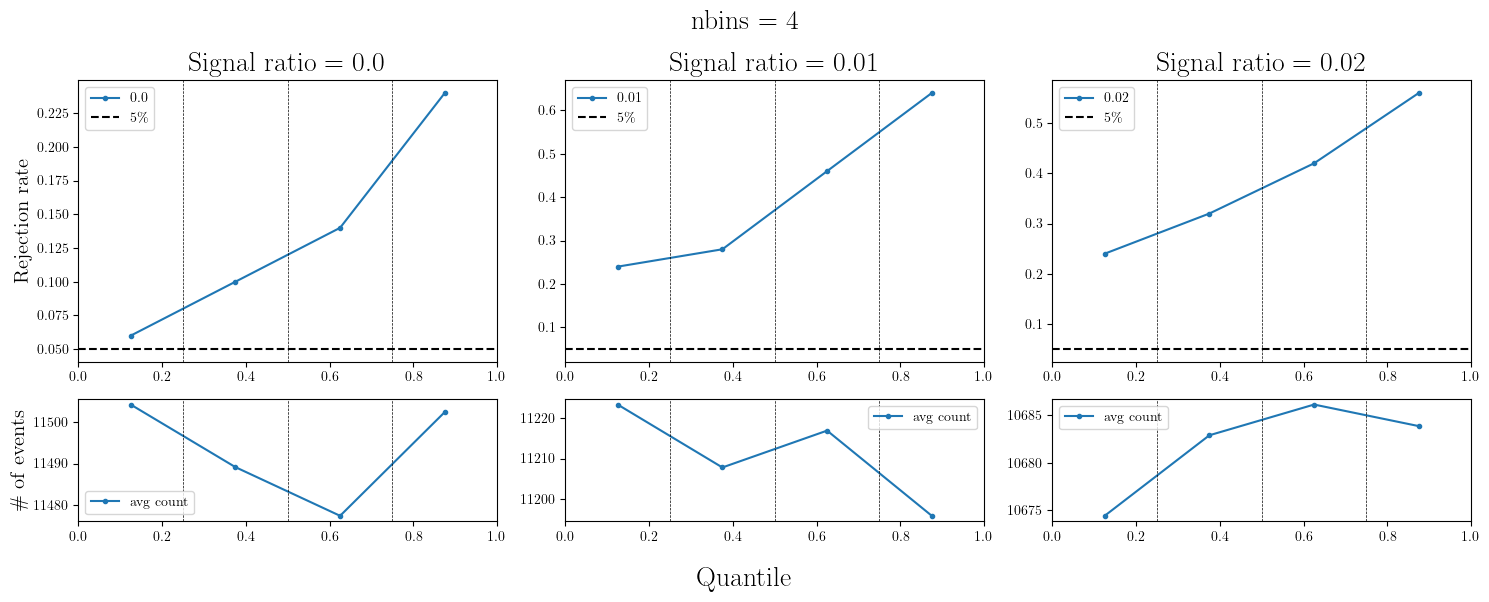

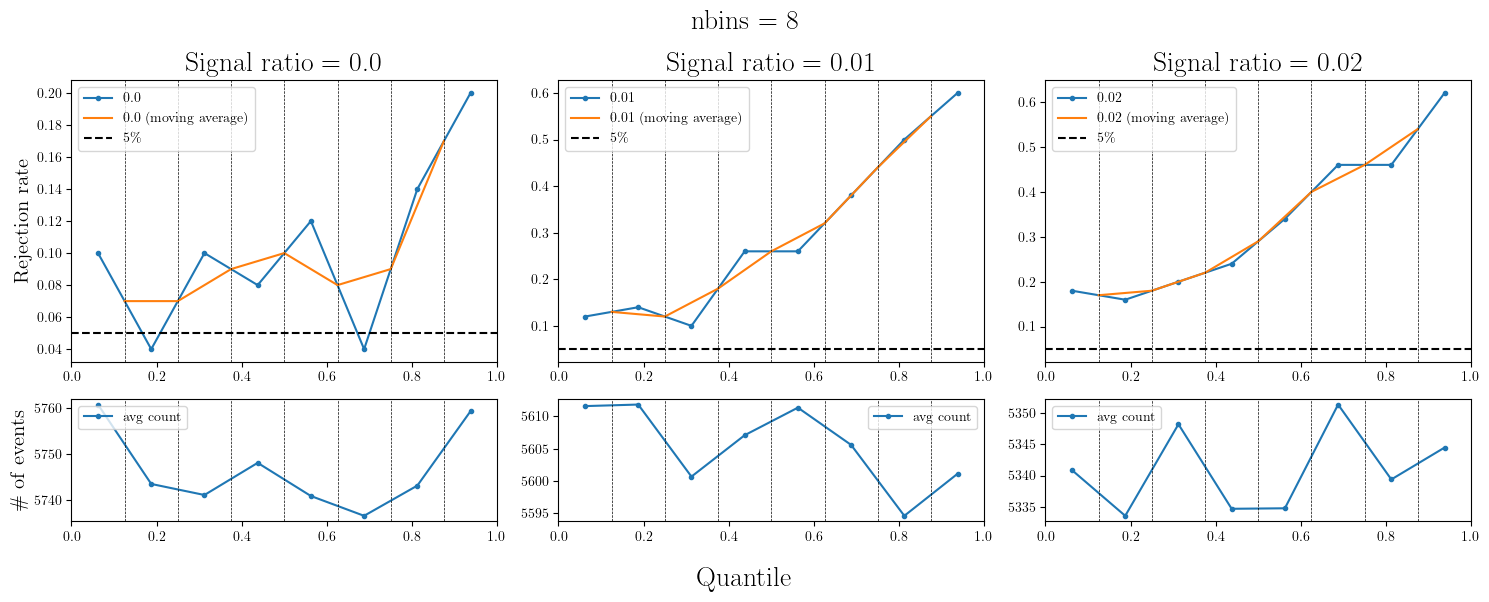

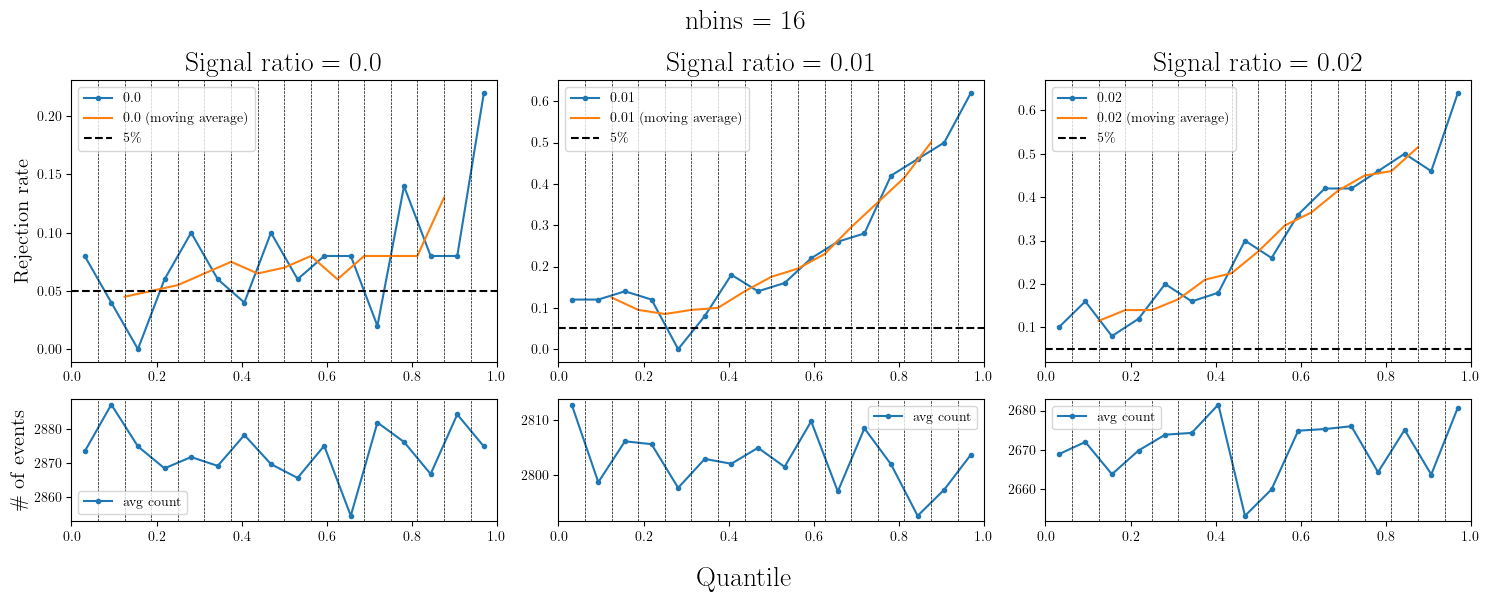

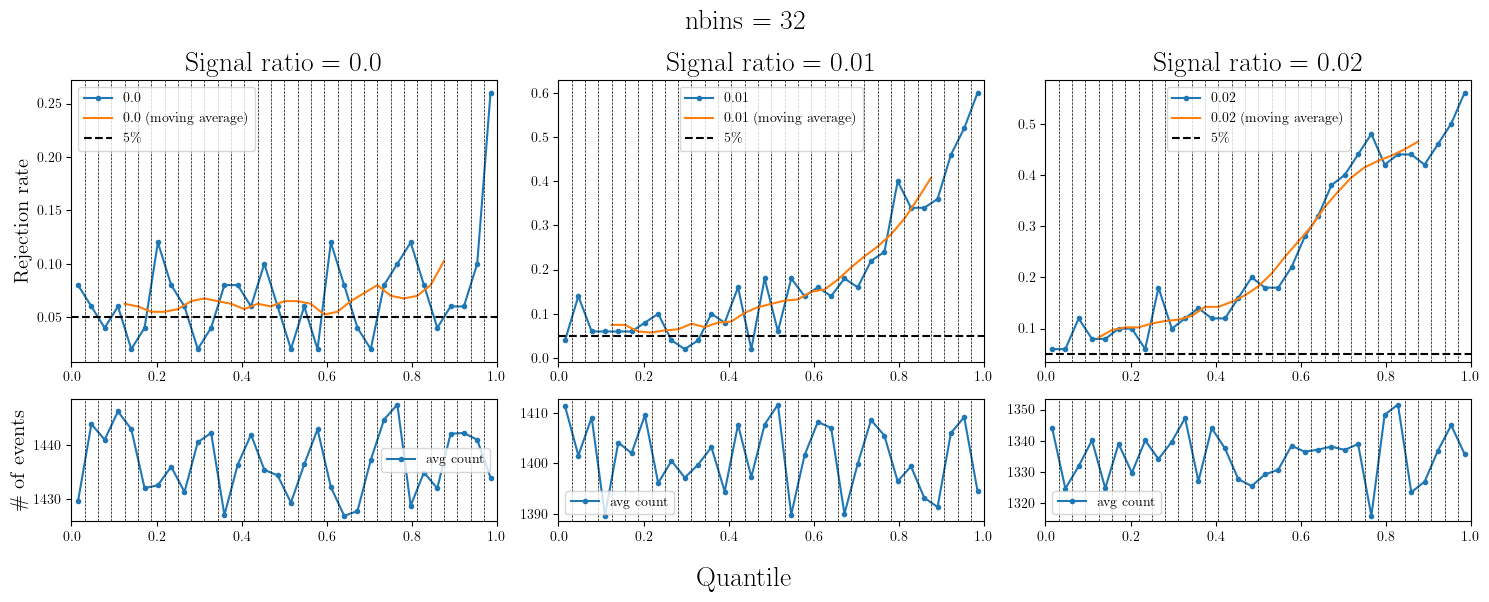

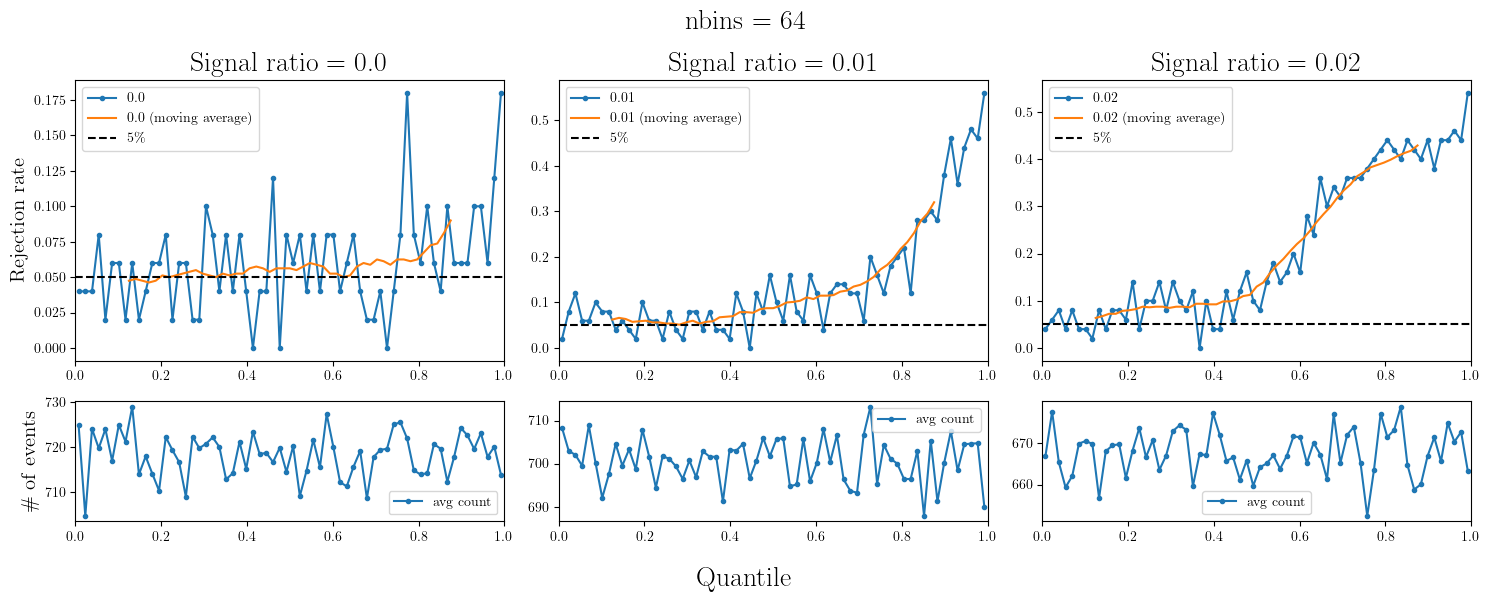

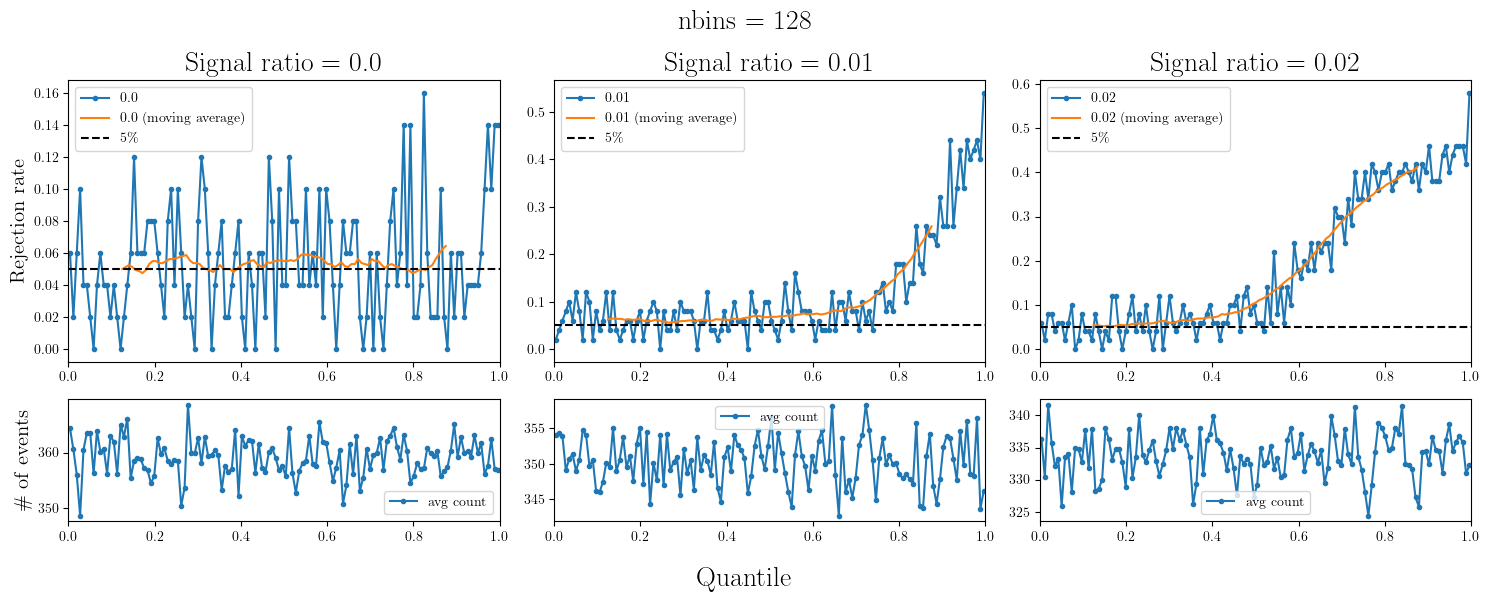

In [58]:
for nbins in [2**i for i in range(2, 8)]:
    window_size = nbins // 4
    fig = plt.figure(figsize=(15, 6))
    fig.suptitle(f"nbins = {nbins}")
    fig.supxlabel("Quantile")
    gs = fig.add_gridspec(3, 3)
    for i, signal_ratio in enumerate([0.0, 0.01, 0.02]):
        rejection_rate = [rej_df.loc[(nbins, i, i+1, signal_ratio), "rejected"].mean() for i in range(nbins)]
        ax = fig.add_subplot(gs[0:2, i])
        if i == 0:
            ax.set_ylabel("Rejection rate")
        ax.set_title(f"Signal ratio = {signal_ratio}")
        ax.plot((np.arange(nbins) + 1 / 2) / nbins, rejection_rate, "o-", label=f"{signal_ratio}")
        # moving average
        if window_size > 1:
            rejection_rate = np.convolve(rejection_rate, np.ones((window_size,))/window_size, mode='valid')
            ax.plot((np.arange(len(rejection_rate)) + window_size / 2) / nbins, rejection_rate, label=f"{signal_ratio} (moving average)")
        ax.axhline(0.05, color="black", linestyle="--", label="5\%")
        if nbins < 2**6:
            for pos in np.arange(nbins + 1) / nbins:
                ax.axvline(pos, color="black", linestyle="--", linewidth=0.5)
        ax.legend()
        ax.set_xlim(0, 1)
        
        ax = fig.add_subplot(gs[2, i])
        avg_counts = [rej_df.loc[(nbins, i, i+1, signal_ratio), "counts"].mean() for i in range(nbins)]
        if i == 0:
            ax.set_ylabel("\# of events")
        ax.plot((np.arange(nbins) + 1 / 2) / nbins, avg_counts, "o-", label="avg count")
        if nbins < 2**6:
            for pos in np.arange(nbins + 1) / nbins:
                ax.axvline(pos, color="black", linestyle="--", linewidth=0.5)
        ax.legend()
        ax.set_xlim(0, 1)
        
    plt.tight_layout()
    plt.show()

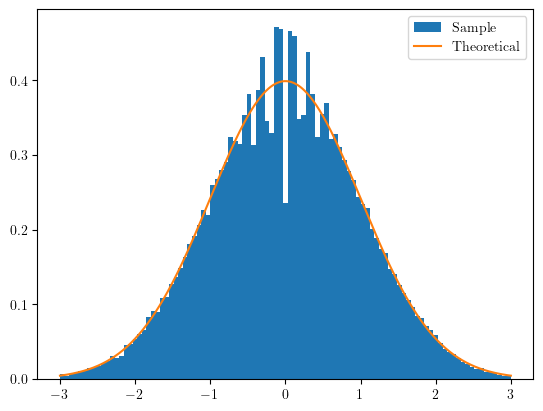

In [27]:
# sample from poisson distribution
lam = 400
n_samples = 100000
samples_1 = np.random.poisson(lam, n_samples)
samples_2 = np.random.poisson(lam, n_samples)
plt.hist((samples_1 - samples_2) / np.sqrt(samples_1 + samples_2), bins=np.linspace(-3, 3, 100), 
         density=True, label="Sample")
# theoretical distribution
x = np.linspace(-3, 3, 1000)
plt.plot(x, stats.norm.pdf(x, loc=0, scale=1), label="Theoretical")
plt.legend()
plt.show()


/tmp/ipykernel_57826/1198149233.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  plt.boxplot([rej_df.loc[(nbins, i, i+1, signal_ratio), "pull"] for i in range(nbins)],


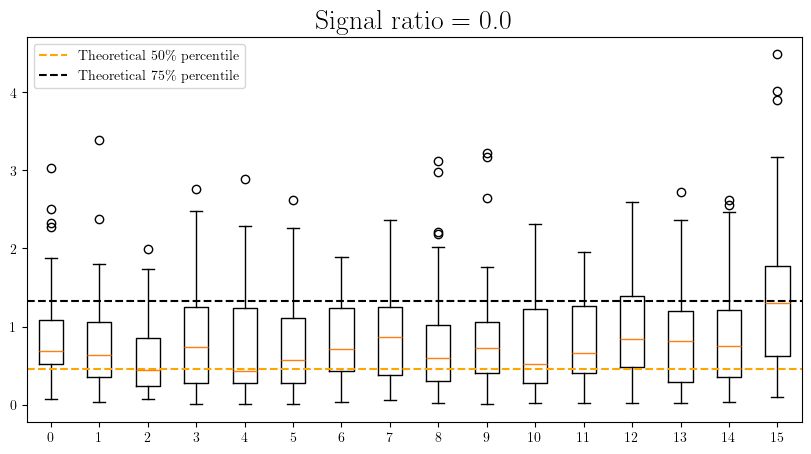

/tmp/ipykernel_57826/1198149233.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  plt.boxplot([rej_df.loc[(nbins, i, i+1, signal_ratio), "pull"] for i in range(nbins)],


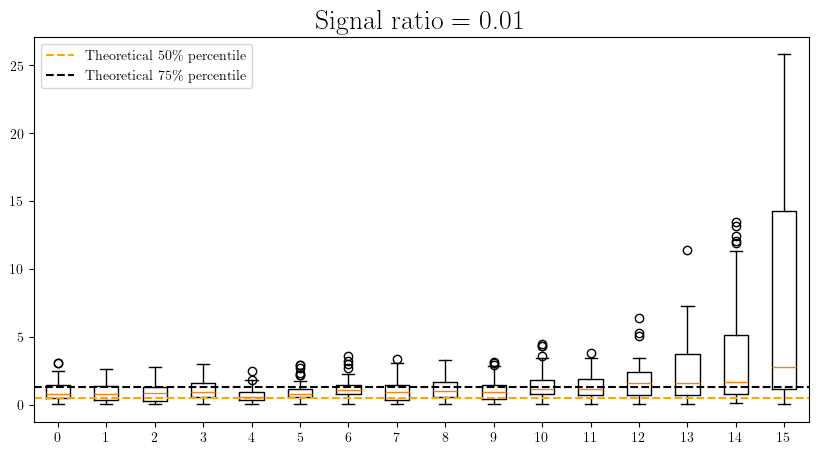

/tmp/ipykernel_57826/1198149233.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  plt.boxplot([rej_df.loc[(nbins, i, i+1, signal_ratio), "pull"] for i in range(nbins)],


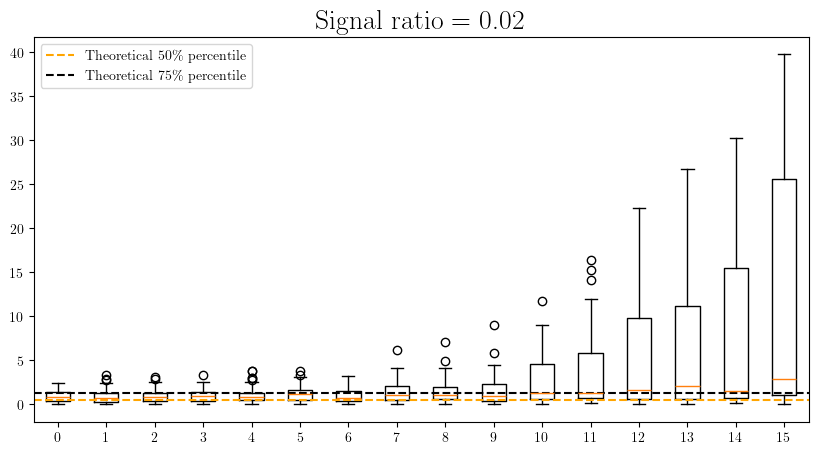

In [11]:
nbins = 2**4
for signal_ratio in [0.0, 0.01, 0.02]:
    plt.figure(figsize=(10, 5))
    plt.title(f"Signal ratio = {signal_ratio}")
    plt.boxplot([rej_df.loc[(nbins, i, i+1, signal_ratio), "pull"] for i in range(nbins)], 
                positions=np.arange(nbins), widths=0.5)
    plt.axhline(stats.chi2.ppf(0.5, df=1), color="orange", linestyle="--", label="Theoretical 50\% percentile")
    plt.axhline(stats.chi2.ppf(0.75, df=1), color="black", linestyle="--", label="Theoretical 75\% percentile")
    plt.legend()
    plt.show()

In [12]:
for signal_ratio in [0.0, 0.01, 0.02]:
    print(f"{signal_ratio}: {rej_df.loc[(2**5, 2 * 2**3, 3 * 2**3, signal_ratio), 'rejected'].mean()}")


0.0: 0.06
0.01: 0.32
0.02: 0.42


/tmp/ipykernel_57826/2194571401.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  print(f"{signal_ratio}: {rej_df.loc[(2**5, 2 * 2**3, 3 * 2**3, signal_ratio), 'rejected'].mean()}")


In [14]:
for nbins in [2**i for i in range(2, 6)]:
    for signal_ratio in [0.0, 0.01, 0.02]:
        print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, 0, nbins // 4, signal_ratio)]['rejected'].mean()}")
        print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, nbins // 4, nbins // 2, signal_ratio)]['rejected'].mean()}")
        print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, nbins // 2, nbins // 4 * 3, signal_ratio)]['rejected'].mean()}")
        print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, nbins // 4 * 3, nbins, signal_ratio)]['rejected'].mean()}")
    
for nbins in [2**i for i in range(2, 6)]:
    for signal_ratio in [0.0]:
        print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, 0, nbins // 4, signal_ratio)]['p'].mean()}")
        print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, nbins // 4, nbins // 2, signal_ratio)]['p'].mean()}")
        print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, nbins // 2, nbins // 4 * 3, signal_ratio)]['p'].mean()}")
        print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, nbins // 4 * 3, nbins, signal_ratio)]['p'].mean()}")
    

4: 0.0: 0.06
4: 0.0: 0.12
4: 0.0: 0.14
4: 0.0: 0.26
4: 0.01: 0.22
4: 0.01: 0.26
4: 0.01: 0.42
4: 0.01: 0.64
4: 0.02: 0.2
4: 0.02: 0.28
4: 0.02: 0.46
4: 0.02: 0.56
8: 0.0: 0.06
8: 0.0: 0.08
8: 0.0: 0.1
8: 0.0: 0.26
8: 0.01: 0.22
8: 0.01: 0.24
8: 0.01: 0.38
8: 0.01: 0.58
8: 0.02: 0.18
8: 0.02: 0.28
8: 0.02: 0.44
8: 0.02: 0.6
16: 0.0: 0.08
16: 0.0: 0.06
16: 0.0: 0.1
16: 0.0: 0.22
16: 0.01: 0.18
16: 0.01: 0.24
16: 0.01: 0.36
16: 0.01: 0.62
16: 0.02: 0.2
16: 0.02: 0.26
16: 0.02: 0.42
16: 0.02: 0.62
32: 0.0: 0.08
32: 0.0: 0.02
32: 0.0: 0.06
32: 0.0: 0.24
32: 0.01: 0.18
32: 0.01: 0.2
32: 0.01: 0.32
32: 0.01: 0.62
32: 0.02: 0.2
32: 0.02: 0.26
32: 0.02: 0.42
32: 0.02: 0.54
4: 0.0: 0.41848937263436453
4: 0.0: 0.3666042536183502
4: 0.0: 0.4570696053109431
4: 0.0: 0.3613287286306761
8: 0.0: 0.44699323608493946
8: 0.0: 0.39634811744972626
8: 0.0: 0.4989720470656468
8: 0.0: 0.32650806350083994
16: 0.0: 0.5273446988721812
16: 0.0: 0.45745057507114906
16: 0.0: 0.4899000056234501
16: 0.0: 0.31819129471

/tmp/ipykernel_57826/596967804.py:3: PerformanceWarning: indexing past lexsort depth may impact performance.
  print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, 0, nbins // 4, signal_ratio)]['rejected'].mean()}")
/tmp/ipykernel_57826/596967804.py:4: PerformanceWarning: indexing past lexsort depth may impact performance.
  print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, nbins // 4, nbins // 2, signal_ratio)]['rejected'].mean()}")
/tmp/ipykernel_57826/596967804.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, nbins // 2, nbins // 4 * 3, signal_ratio)]['rejected'].mean()}")
/tmp/ipykernel_57826/596967804.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  print(f"{nbins}: {signal_ratio}: {rej_df.loc[(nbins, nbins // 4 * 3, nbins, signal_ratio)]['rejected'].mean()}")
/tmp/ipykernel_57826/596967804.py:10: PerformanceWarning: indexing past lexsort depth may impact performan

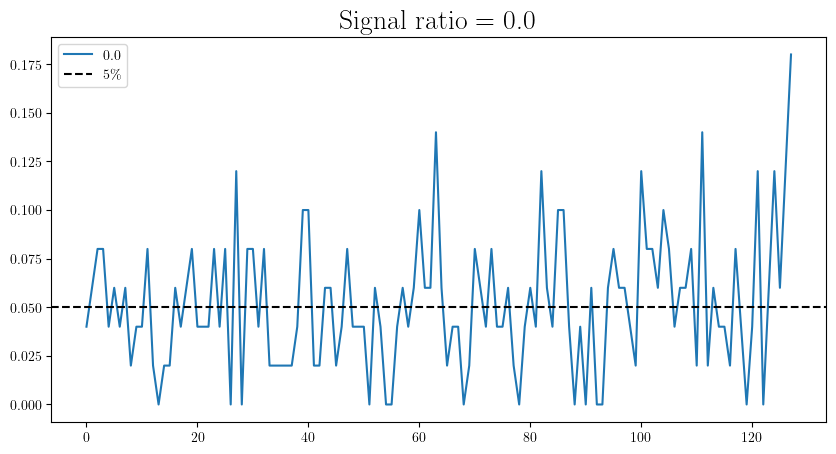

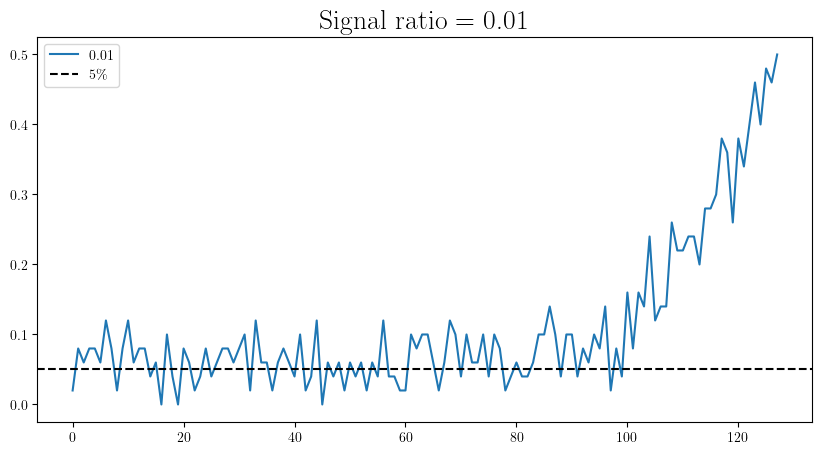

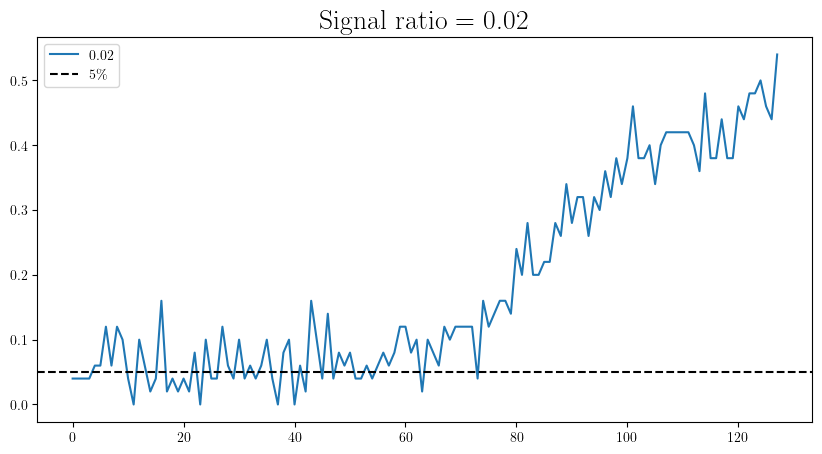

In [54]:
nbins = 2**7
learning_mode = "orig"
model = "AttentionClassifier" if learning_mode == "repr" else "FvTClassifier"
tmp = [h for h in hist_list if (h["nbins"] == nbins and h["mode"] == "quantile" and h["model"] == model)]
window_size = nbins // nbins

stat_array = {(signal_ratio, pos): np.array([]) for signal_ratio in [0.0, 0.01, 0.02] for pos in range(nbins - window_size + 1)}
for h in tmp:
    diff_SR = h["diff_SR"]
    sq_SR = h["sq_SR"]
    for pos in range(nbins - window_size + 1):
        diff = np.sum(diff_SR[pos:pos+window_size])
        sq = np.sum(sq_SR[pos:pos+window_size])
        stat_array[(h["signal_ratio"], pos)] = np.append(stat_array[(h["signal_ratio"], pos)], diff**2 / sq)

z = stats.chi2.ppf(0.95, df=1)
for signal_ratio in [0.0, 0.01, 0.02]:
    rejs = [np.mean(stat_array[(signal_ratio, pos)] > z) for pos in range(nbins - window_size + 1)]
    plt.figure(figsize=(10, 5))
    plt.title(f"Signal ratio = {signal_ratio}")
    plt.plot(rejs, label=f"{signal_ratio}")
    plt.axhline(0.05, color="black", linestyle="--", label="5\%")
    plt.legend()
    plt.show()
